# Text Extraction with Gemini

In this notebook we will prompt Google's Gemini to extract the transliterated texts from our 387 PDF pages. First, we will determine how we want this text extraction output to look like and devise a JSON schema.

## Requirements

You will need the following libraries:
* [pypdf](https://pypi.org/project/pypdf/): A pure-python PDF library capable of splitting, merging, cropping, and transforming PDF files
* [pdf2image](https://pypi.org/project/pdf2image/): A python (3.7+) module that wraps pdftoppm and pdftocairo to convert PDF to a PIL Image object
  * To use this library on a Mac you need [poppler](https://poppler.freedesktop.org/), which is installed using [Brew](https://brew.sh/)
* Optionally: matplotlib to display images of PDF pages more neatly
* [google.genai]()

In [1]:
import os
import matplotlib.pyplot as plt
from pdf2image import convert_from_path
from pypdf import PdfReader
import json

## Designing the desired output

### Why LLMs?

One of the biggest advantages of using a multimodal large language model like Gemini for text extraction, compared to OCR software, is that these models allow us to modify the extraction process.

The output of OCR software is often a txt file. OCR software does not retain information about whether a line was bold or in a larger font. It turns everything into plain text. While there are ways to retain this type of information, like extracting text into HTML, this is not always reliable. In the next notebook we will explore this in more detail by using ABBYY FineReader as a comparative example.

To briefly illustrate, the code below shows the first image of the transliteration and the OCR'd version of that same page. The OCR'd version was already in the PDF, embedded as a text layer. This is not the case for all PDFs, as some are just images without text layers. This one happens to be OCR'd with the output retained as the text layer. pypdf's extract_text() function would return an empty string if there wasn't a text layer in the PDF already.

/var/folders/gy/ywyy6xk56n586rs2nxmry_b40000gn/T/ipykernel_60230/2878215474.py:33: UserWarning: Glyph 64608 (\N{ARABIC LIGATURE SHADDA WITH FATHA ISOLATED FORM}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/gy/ywyy6xk56n586rs2nxmry_b40000gn/T/ipykernel_60230/2878215474.py:33: UserWarning: Glyph 158 (\x9e) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/mervetekgurler/anaconda3/envs/ottoman-court-histories/lib/python3.14/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 64608 (\N{ARABIC LIGATURE SHADDA WITH FATHA ISOLATED FORM}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mervetekgurler/anaconda3/envs/ottoman-court-histories/lib/python3.14/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 158 (\x9e) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


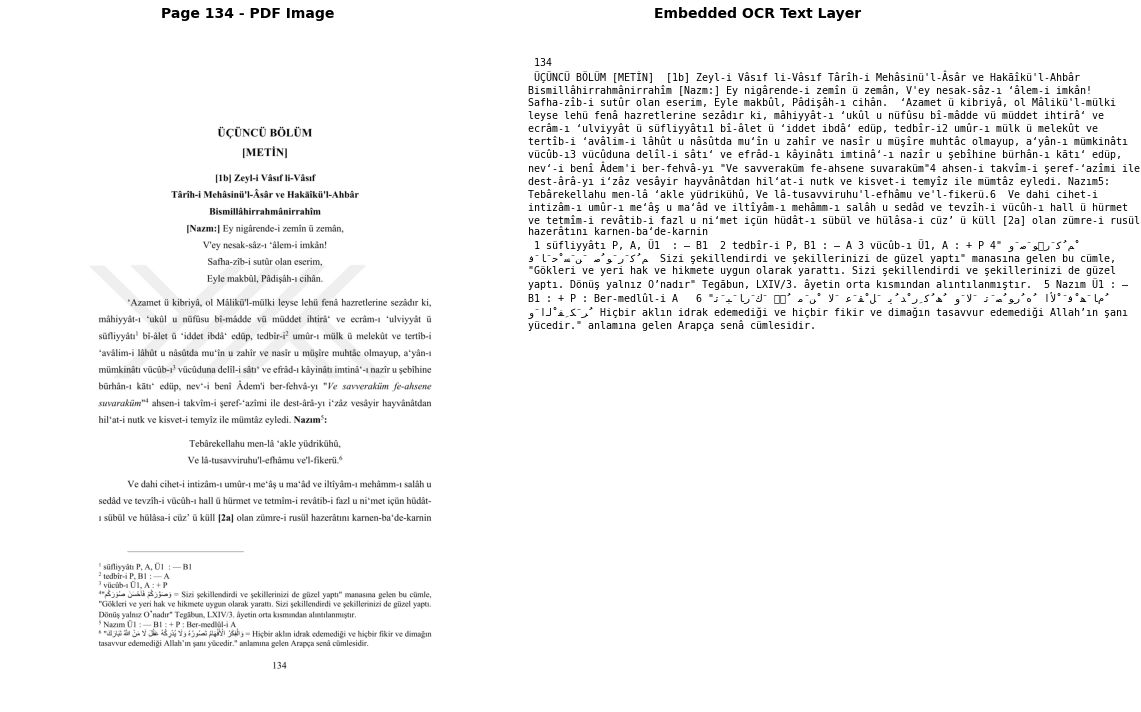

In [2]:
import os
import matplotlib.pyplot as plt
from pdf2image import convert_from_path
from pypdf import PdfReader

# Path to your first transliteration page
pages_folder = 'transliteration_pages'
first_page_file = os.path.join(pages_folder, 'page_134.pdf')

# Convert PDF to image
images = convert_from_path(first_page_file)
page_image = images[0]

# Extract embedded OCR text layer from the PDF
reader = PdfReader(first_page_file)
ocr_text = reader.pages[0].extract_text()

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Left: PDF image
axes[0].imshow(page_image)
axes[0].set_title('Page 134 - PDF Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Right: OCR text
axes[1].text(0.05, 0.95, ocr_text, transform=axes[1].transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             wrap=True)
axes[1].set_title('Embedded OCR Text Layer', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

This example also illustrates a key disadvantage of commercial OCR software: it doesn't perform well with texts containing multiple scripts. Scholarly editions of Ottoman Turkish works are transliterated into Latin script, but they frequently include Arabic or Ottoman Turkish passages in the original Arabic script—for example, to show historical spellings or variant readings across different manuscript copies. Multimodal LLMs handle these mixed-script pages much more effectively than traditional OCR software.

### What is the ideal output that we want?

Let's take a closer look at a couple of random pages to gain a deeper understanding of the structure of our text.

In [5]:
# Choosing the random pages
# I am keeping this code for instructional purposes. I will get 4 random pages by running this code once and hardcoding the page numbers.

import random
pages_folder = 'transliteration_pages'

all_pages = [f for f in os.listdir(pages_folder) if f.endswith('.pdf')]

# Select 4 random pages
random_pages = random.sample(all_pages, 4)
print(f"Selected pages: {random_pages}")

Selected pages: ['page_355.pdf', 'page_154.pdf', 'page_507.pdf', 'page_256.pdf']


In [6]:
example_pages = ['page_355.pdf', 'page_154.pdf', 'page_507.pdf', 'page_256.pdf']

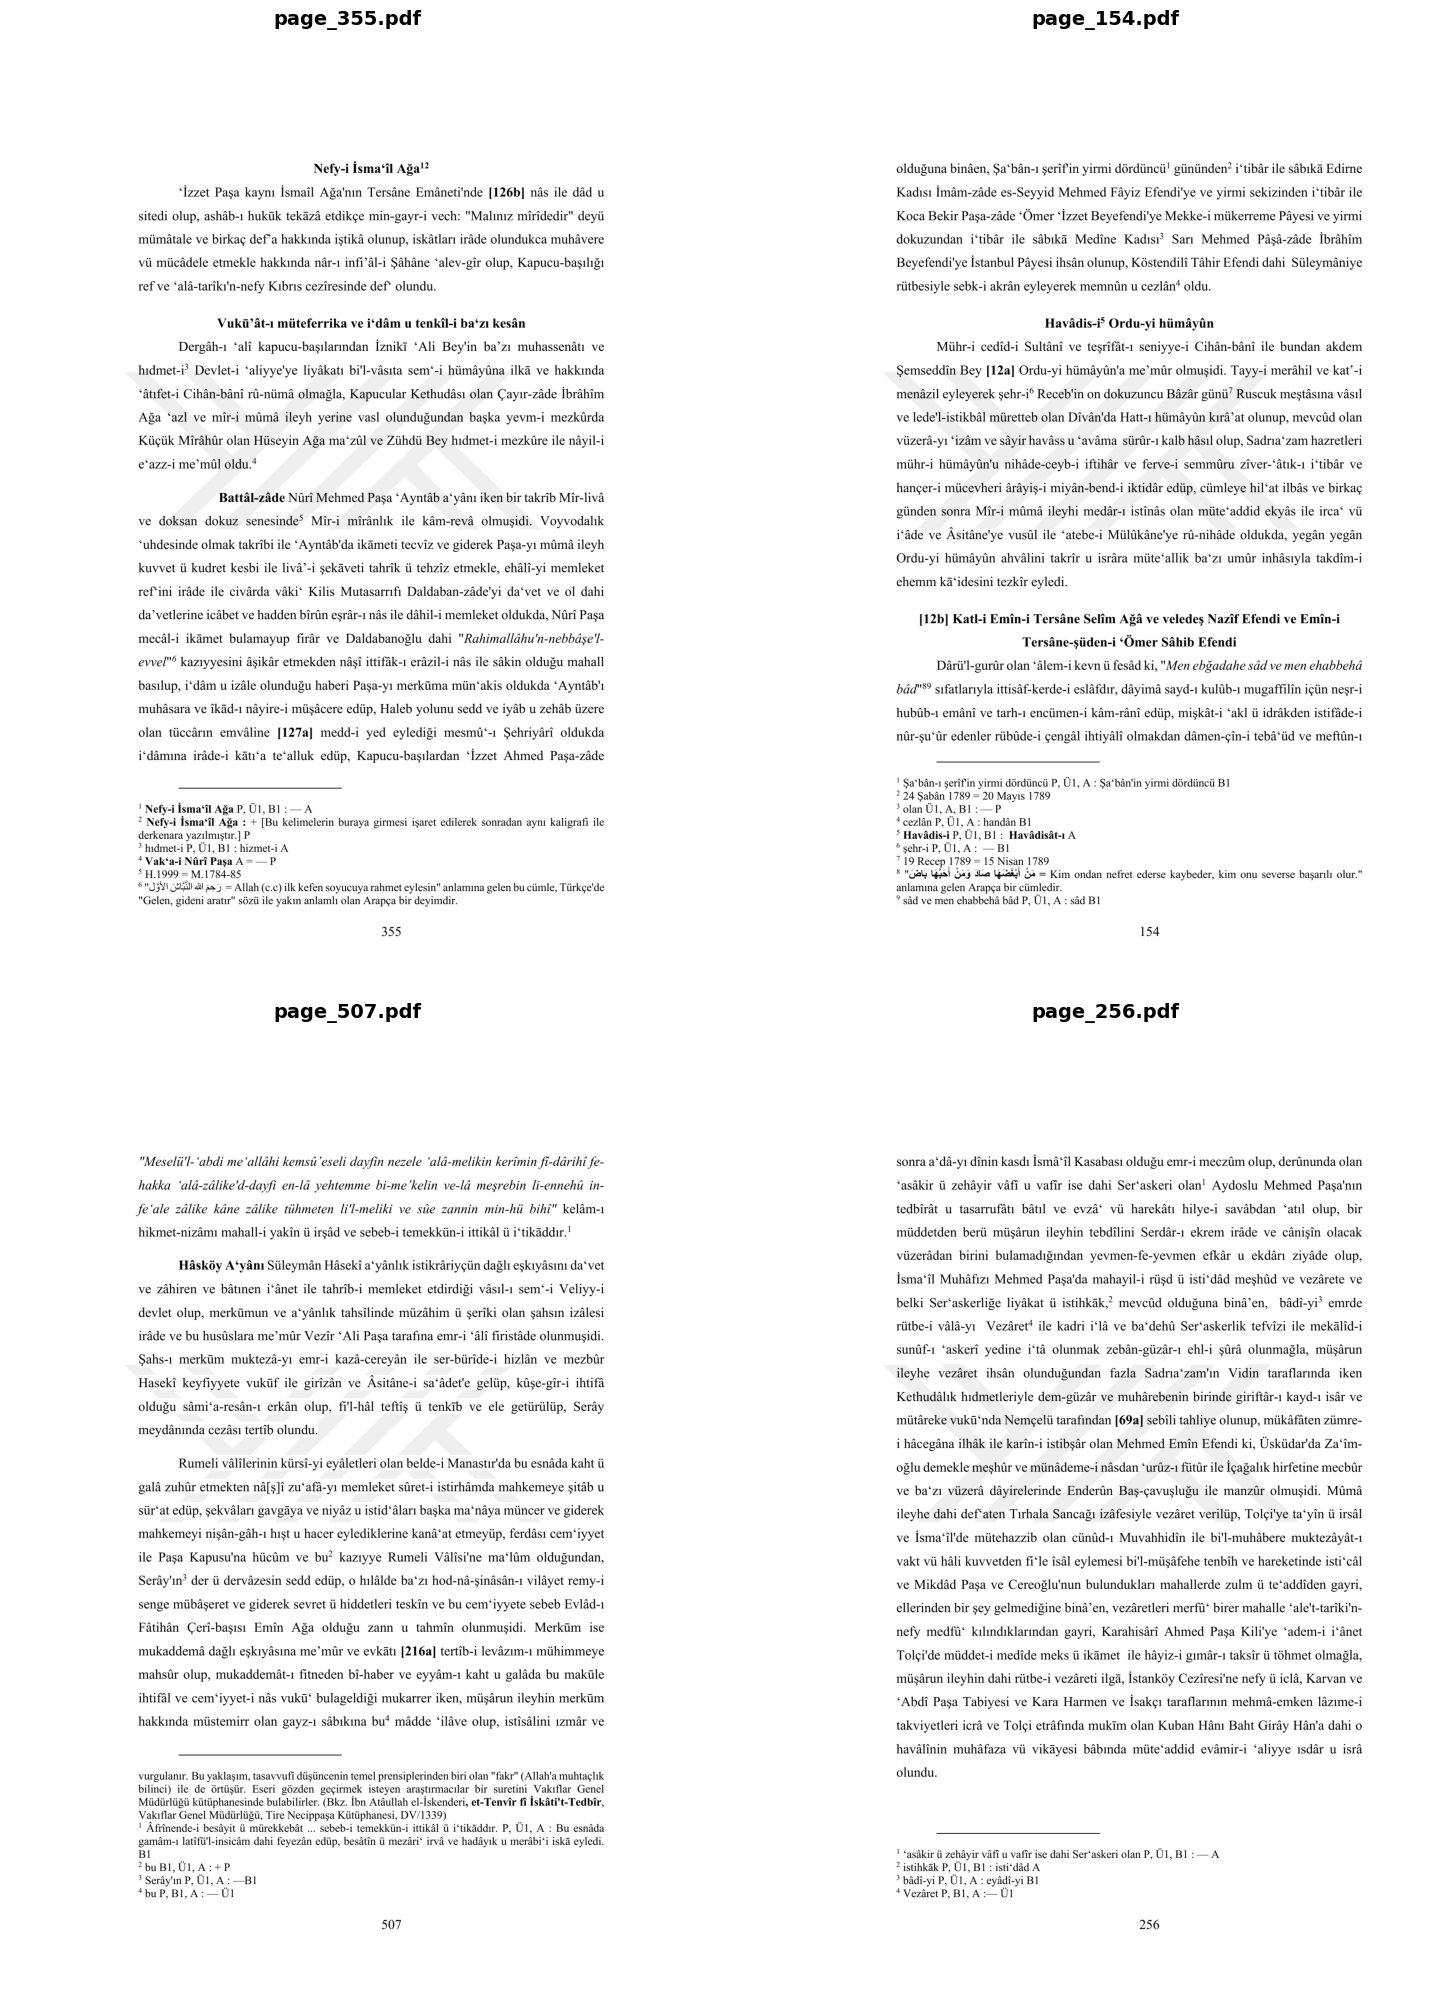

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, page_file in enumerate(example_pages):
    page_path = os.path.join(pages_folder, page_file)
    
    # Convert PDF to image
    images = convert_from_path(page_path)
    page_image = images[0]
    
    # Display
    axes[idx].imshow(page_image)
    axes[idx].set_title(f'{page_file}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

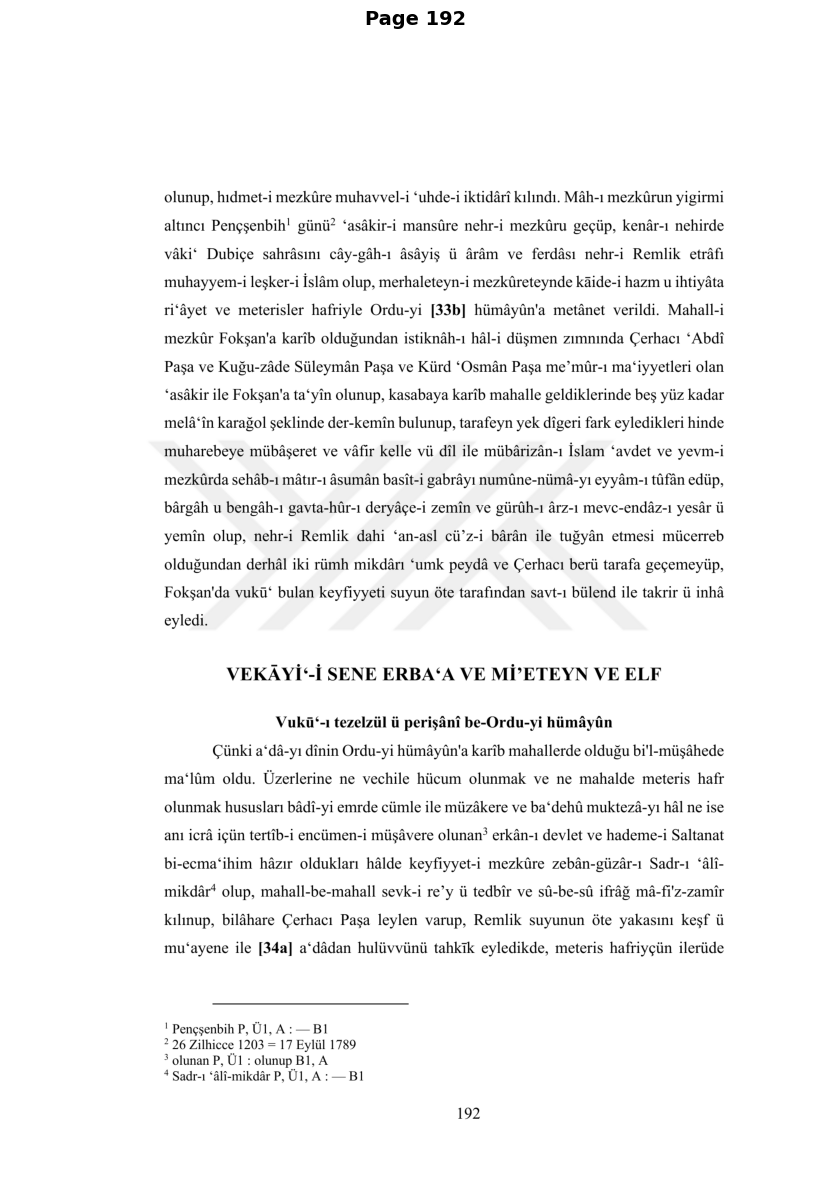

In [8]:
# Let's also take a look at the page 192

page_path = os.path.join(pages_folder, 'page_192.pdf')

# Convert PDF to image
images = convert_from_path(page_path)
page_image = images[0]

# Display
plt.figure(figsize=(10, 12))
plt.imshow(page_image)
plt.title('Page 192', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

This transliterated manuscript, as detailed in the overview, is a history of the years 1203-1209 in the Islamic calendar, or 1789-1794 CE. As is customary with Ottoman histories, the text begins with a general introduction and continues with the events of the first year it covers, or however much remains of that year. The first major structural break occurs at the transition into the next year. In this work, the transition from year 1203 to year 1204 takes place on page 192 and is marked with a bold, all-caps heading: VEKĀYİʻ-İ SENE ERBAʻA VE Mİ'ETEYN VE ELF (the events of the year 1204).

Looking at the page examples above, we can see that there are some bold lines in bookcase and in the same font as the main body of the text: "Vukū’ât-ı müteferrika ve i‘dâm u tenkîl-i ba‘zı kesân" or "Havâdis-i Ordu-yi hümâyûn".These represent the beginning of individual 'events' for each year. Sometimes rather than narrating events, Ottoman histories wrote commentaries or copied texts from other documents like treaties but for the purposes of the text extraction, we can call them all events, fitting with the year headings expressed as "the events of the year XXXX".

Also visible in the examples are manuscript page numbers like \[126b\] or \[34a\]. These numbers refer to the original manuscript pages from which this transliteration as produced. They build a connection between the original text and its scholarly edition, allowing historians to go back to the source and cross-reference if need be.  

Additionally we see footnotes on each page, often showing small variance between different copies of the same manuscript ("olunan, P, Ü1: olunup B1, A") or translating a quote or a phrase from Arabic ("'مَنْ أَبْغَضَهَا صَادَ وَمَنْ أَحَبَّهَا بَاضَ = Kim ondan nefret ederse kaybeder, kim onu severse başarılı olur.' anlamına gelen Arapça bir cümledir.") The footnotes in this work restart from 1 in each page. In other works, they might be continues thoughout the entire text.


Based on this information, we can say that the structure of this whole work is:

- introduction (pages 134-142)
- rest of the year 1203 (pages 143-192)
  - several events starting with the accession of Sultan Selim III in 11 Recep 1203 = 7 Nisan 1789
- year 1204 (pages 192ff)
  - several events ...
- repeats for each year 1205, 1206, 1207, 1208
  - several events ...
- the beginning of the year 1209, which continues in a different manuscript (pages 518-520)
  - handful events

Basically, the smallest unit of information for this work is the event. Each event has a subheading and a body of text. Each event belongs to a year. This is the key to designing the text extraction.

Here is what we want:

This is one event from page 154 printed above

![Event example from page 154](one_event_pg154.png)

Its subheading is: Havâdis-i Ordu-yi hümâyûn

Its body of text is: Mühr-i  cedîd-i  Sultânî  ve  teşrîfât-ı  seniyye-i  Cihân-bânî  ile  bundan  akdem Şemseddîn Bey [12a] Ordu-yi hümâyûn'a me’mûr olmuşidi. Tayy-i merâhil ve katʽ-i menâzil eyleyerek şehr-i Receb'in on dokuzuncu Bâzâr günü Ruscuk meştâsına vâsıl ve lede'l-istikbâl müretteb olan Dîvân'da Hatt-ı hümâyûn kırâ’at olunup, mevcûd olan vüzerâ-yı ʻizâm ve sâyir havâss u ʻavâma  sürûr-ı kalb hâsıl olup, Sadrıaʻzam hazretleri mühr-i  hümâyûn'u  nihâde-ceyb-i  iftihâr  ve  ferve-i  semmûru  zîver-ʻâtık-ı  i‘tibâr  ve hançer-i mücevheri ârâyiş-i miyân-bend-i iktidâr edüp, cümleye hilʻat ilbâs ve birkaç günden sonra Mîr-i mûmâ ileyhi medâr-ı istînâs olan müteʻaddid ekyâs ile ircaʻ vü iʻâde ve Âsitâne'ye vusûl ile ʻatebe-i Mülûkâne'ye rû-nihâde oldukda, yegân yegân Ordu-yi  hümâyûn  ahvâlini  takrîr  u  isrâra  müteʻallik  baʻzı  umûr  inhâsıyla  takdîm-i ehemm kāʻidesini tezkîr eyledi.

Note that I removed the footnotes but left the manuscript page number in the text.

As such the JSON should look like this:

```json
{
  "page": 154,
  "event": {
    "subheading": "Havâdis-i Ordu-yi hümâyûn",
    "body": "Mühr-i cedîd-i Sultânî ve teşrîfât-ı seniyye-i Cihân-bânî ile bundan akdem Şemseddîn Bey [12a] Ordu-yi hümâyûn'a me'mûr olmuşidi. Tayy-i merâhil ve katʽ-i menâzil eyleyerek şehr-i Receb'in on dokuzuncu Bâzâr günü Ruscuk meştâsına vâsıl ve lede'l-istikbâl müretteb olan Dîvân'da Hatt-ı hümâyûn kırâ'at olunup, mevcûd olan vüzerâ-yı ʻizâm ve sâyir havâss u ʻavâma sürûr-ı kalb hâsıl olup, Sadrıaʻzam hazretleri mühr-i hümâyûn'u nihâde-ceyb-i iftihâr ve ferve-i semmûru zîver-ʻâtık-ı i'tibâr ve hançer-i mücevheri ârâyiş-i miyân-bend-i iktidâr edüp, cümleye hilʻat ilbâs ve birkaç günden sonra Mîr-i mûmâ ileyhi medâr-ı istînâs olan müteʻaddid ekyâs ile ircaʻ vü iʻâde ve Âsitâne'ye vusûl ile ʻatebe-i Mülûkâne'ye rû-nihâde oldukda, yegân yegân Ordu-yi hümâyûn ahvâlini takrîr u isrâra müteʻallik baʻzı umûr inhâsıyla takdîm-i ehemm kāʻidesini tezkîr eyledi."
  }
}
```


Let's translate this into a full page example, staying with page 154.

```json
{
  "page": 154,
  "events": [
    {
      "subheading": null,
      "body": "olduğuna binâen, Şaʻbân-ı şerîf'in yirmi dördüncü gününden iʻtibâr ile sâbıkā Edirne Kadısı İmâm-zâde es-Seyyid Mehmed Fâyiz Efendi'ye ve yirmi sekizinden iʻtibâr ile Koca Bekir Paşa-zâde ʻÖmer ʻİzzet Beyefendi'ye Mekke-i mükerreme Pâyesi ve yirmi dokuzundan iʻtibâr ile sâbıkā Medîne Kadısı Sarı Mehmed Pâşâ-zâde İbrâhîm Beyefendi'ye İstanbul Pâyesi ihsân olunup, Köstendilî Tâhir Efendi dahi Süleymâniye rütbesiyle sebk-i akrân eyleyerek memnûn u cezlân oldu."
    },
    {
      "subheading": "Havâdis-i Ordu-yi hümâyûn",
      "body": "Mühr-i cedîd-i Sultânî ve teşrîfât-ı seniyye-i Cihân-bânî ile bundan akdem Şemseddîn Bey [12a] Ordu-yi hümâyûn'a me'mûr olmuşidi. Tayy-i merâhil ve katʽ-i menâzil eyleyerek şehr-i Receb'in on dokuzuncu Bâzâr günü Ruscuk meştâsına vâsıl ve lede'l-istikbâl müretteb olan Dîvân'da Hatt-ı hümâyûn kırâ'at olunup, mevcûd olan vüzerâ-yı ʻizâm ve sâyir havâss u ʻavâma sürûr-ı kalb hâsıl olup, Sadrıaʻzam hazretleri mühr-i hümâyûn'u nihâde-ceyb-i iftihâr ve ferve-i semmûru zîver-ʻâtık-ı i'tibâr ve hançer-i mücevheri ârâyiş-i miyân-bend-i iktidâr edüp, cümleye hilʻat ilbâs ve birkaç günden sonra Mîr-i mûmâ ileyhi medâr-ı istînâs olan müteʻaddid ekyâs ile ircaʻ vü iʻâde ve Âsitâne'ye vusûl ile ʻatebe-i Mülûkâne'ye rû-nihâde oldukda, yegân yegân Ordu-yi hümâyûn ahvâlini takrîr u isrâra müteʻallik baʻzı umûr inhâsıyla takdîm-i ehemm kāʻidesini tezkîr eyledi."
    },
    {
      "subheading": "[12b] Katl-i Emîn-i Tersâne Selîm Ağâ ve veledeş Nazîf Efendi ve Emîn-i Tersâne-şüden-i ʻÖmer Sâhib Efendi",
      "body": "Dârü'l-gurûr olan ʻâlem-i kevn ü fesâd ki, \"Men ebğadahe sâd ve men ehabbehâ bâd\" sıfatlarıyla ittisâf-kerde-i eslâfdır, dâyimâ sayd-ı kulûb-ı mugaffilîn içün neşr-i hubûb-ı emânî ve tarh-ı encümen-i kâm-rânî edüp, mişkât-i ʻakl ü idrâkden istifâde-i nûr-şuʻûr edenler rübûde-i çengâl ihtiyâlî olmakdan dâmen-çîn-i tebâʻüd ve meftûn-ı"
    }
  ]
}
```

How do we then deal with a year heading in this structure?

We map it as an event with only a subheading, see page 192

```json
{
  "page": 192,
  "events": [
    {
      "subheading": null,
      "body": "olunup, hıdmet-i mezkûre muhavvel-i ʻuhde-i iktidârî kılındı. Mâh-ı mezkûrun yigirmi altıncı Pençşenbih günü ʻasâkir-i mansûre nehr-i mezkûru geçüp, kenâr-ı nehirde vâkiʻ  Dubiçe  sahrâsını  cây-gâh-ı  âsâyiş  ü  ârâm  ve  ferdâsı  nehr-i  Remlik  etrâfı muhayyem-i leşker-i İslâm olup, merhaleteyn-i mezkûreteynde kāide-i hazm u ihtiyâta riʻâyet  ve  meterisler  hafriyle  Ordu-yi  [33b]  hümâyûn'a  metânet  verildi.  Mahall-i mezkûr Fokşan'a karîb olduğundan istiknâh-ı hâl-i düşmen zımnında Çerhacı ʻAbdî Paşa ve Kuğu-zâde Süleymân Paşa ve Kürd ʻOsmân Paşa me’mûr-ı maʻiyyetleri olan ʻasâkir ile Fokşan'a taʻyîn olunup, kasabaya karîb mahalle geldiklerinde beş yüz kadar melâʻîn karağol şeklinde der-kemîn bulunup, tarafeyn yek dîgeri fark eyledikleri hinde muharebeye mübâşeret ve vâfir kelle vü dîl ile mübârizân-ı İslam ʻavdet ve yevm-i mezkûrda sehâb-ı mâtır-ı âsumân basît-i gabrâyı numûne-nümâ-yı eyyâm-ı tûfân edüp, bârgâh u bengâh-ı gavta-hûr-ı deryâçe-i zemîn ve gürûh-ı ârz-ı mevc-endâz-ı yesâr ü yemîn  olup,  nehr-i  Remlik  dahi  ʻan-asl  cü’z-i  bârân  ile  tuğyân  etmesi  mücerreb olduğundan derhâl iki rümh mikdârı ʻumk peydâ ve Çerhacı berü tarafa geçemeyüp, Fokşan'da vukūʻ bulan keyfiyyeti suyun öte tarafından savt-ı bülend ile takrir ü inhâ eyledi."
    },
    {
      "subheading": "VEKĀYİʻ-İ SENE ERBAʻA VE Mİ'ETEYN VE ELF",
      "body": null
    },
    {
      "subheading": "Vukūʻ-ı tezelzül ü perişânî be-Ordu-yi hümâyûn",
      "body": "Çünki aʻdâ-yı dînin Ordu-yi hümâyûn'a karîb mahallerde olduğu bi'l-müşâhede maʻlûm  oldu.  Üzerlerine  ne  vechile  hücum  olunmak  ve  ne  mahalde  meteris  hafr olunmak hususları bâdî-yi emrde cümle ile müzâkere ve baʻdehû muktezâ-yı hâl ne ise anı icrâ içün tertîb-i encümen-i müşâvere olunan erkân-ı devlet ve hademe-i Saltanat bi-ecmaʻihim  hâzır  oldukları  hâlde  keyfiyyet-i  mezkûre  zebân-güzâr-ı  Sadr-ı  ʻâlî-mikdâr olup, mahall-be-mahall sevk-i re’y ü tedbîr ve sû-be-sû ifrâğ mâ-fi'z-zamîr kılınup,  bilâhare  Çerhacı  Paşa  leylen  varup,  Remlik  suyunun  öte  yakasını  keşf  ü muʻayene ile [34a]  aʻdâdan hulüvvünü tahkīk eyledikde, meteris hafriyçün ilerüde"
    }
  ]
}
```

Let's also get some examples where the author used bold to signal something other than an event subheading, like on page 507, which also happens to be a section from an event that began in a previous page and that does not end on this page yet.

```json
{
  "page": 507,
  "events": [
    {
      "subheading": null,
      "body": "\"Meselü'l-‘abdi me‘allâhi kemsû’eseli dayfin nezele ‘alâ-melikin kerîmin fî-dârihî fehakka  ‘alâ-zâlike'd-dayfi  en-lâ  yehtemme  bi-me’kelin  ve-lâ  meşrebin  li-ennehû  infe‘ale  zâlike  kâne  zâlike  tühmeten  li'l-meliki  ve  sûe  zannin  min-hü  bihî\"  kelâm-ı hikmet-nizâmı mahall-i yakîn ü irşâd ve sebeb-i temekkün-i ittikâl ü i‘tikāddır.  
      
      Hâsköy A‘yânı Süleymân Hâsekî a‘yânlık istikrâriyçün dağlı eşkıyâsını da‘vet ve  zâhiren  ve  bâtınen  iʻânet  ile  tahrîb-i  memleket  etdirdiği  vâsıl-ı  semʻ-i  Veliyy-i devlet olup, merkūmun ve a‘yânlık tahsîlinde müzâhim ü şerîki olan şahsın izâlesi irâde ve bu husûslara me’mûr Vezîr ʻAli Paşa tarafına emr-i ʻâlî firistâde olunmuşidi. Şahs-ı  merkūm  muktezâ-yı  emr-i  kazâ-cereyân  ile  ser-bürîde-i  hizlân  ve  mezbûr Hasekî  keyfiyyete  vukūf  ile  girîzân  ve  Âsitâne-i  saʻâdet'e  gelüp,  kûşe-gîr-i  ihtifâ olduğu  sâmi‘a-resân-ı  erkân  olup,  fi'l-hâl  teftîş  ü  tenkīb  ve  ele  getürülüp,  Serây meydânında cezâsı tertîb olundu.  
      
      Rumeli vâlîlerinin kürsî-yi eyâletleri olan belde-i Manastır'da bu esnâda kaht ü galâ zuhûr etmekten nâ[ş]î zuʻafâ-yı memleket sûret-i istirhâmda mahkemeye şitâb u sürʻat edüp, şekvâları gavgāya ve niyâz u istidʻâları başka maʻnâya müncer ve giderek mahkemeyi nişân-gâh-ı hışt u hacer eylediklerine kanâʻat etmeyüp, ferdâsı cemʻiyyet ile  Paşa  Kapusu'na  hücûm  ve  bu  kazıyye  Rumeli  Vâlîsi'ne  maʻlûm  olduğundan, Serây'ın der ü dervâzesin sedd edüp, o hılâlde baʻzı hod-nâ-şinâsân-ı vilâyet remy-i senge mübâşeret ve giderek sevret ü hiddetleri teskîn ve bu cemʻiyyete sebeb Evlâd-ı Fâtihân  Çerî-başısı  Emîn  Ağa  olduğu  zann  u  tahmîn  olunmuşidi.  Merkūm  ise mukaddemâ dağlı eşkıyâsına me’mûr ve evkātı [216a] tertîb-i levâzım-ı mühimmeye mahsûr olup, mukaddemât-ı fitneden bî-haber ve eyyâm-ı kaht u galâda bu makūle ihtifâl ve cemʻiyyet-i nâs vukūʻ bulageldiği mukarrer iken, müşârun ileyhin merkūm hakkında müstemirr olan gayz-ı sâbıkına bu4 mâdde ʻilâve olup, istîsâlini ızmâr ve"
    }
  ]
}

Now that we have carefully studied the PDF and gathered 3 distinct examples, we can now turn them into few-shot examples for prompting Gemini

## Gemini

In [2]:
from dotenv import load_dotenv

load_dotenv() # By default load_dotenv will look for the .env file in the current working directory

api_key = os.getenv("GEMINI_API_KEY")

if api_key:
    print("API key loaded successfully.")

API key loaded successfully.


In [3]:
from google import genai
from google.genai import types

client = genai.Client(api_key=api_key)

In [4]:
# List all available Gemini models
for model in client.models.list():
    print(f"Model: {model.name}")
    print(f"  Display Name: {model.display_name}")
    print(f"  Description: {model.description}")
    print("---")

Model: models/gemini-2.5-flash
  Display Name: Gemini 2.5 Flash
  Description: Stable version of Gemini 2.5 Flash, our mid-size multimodal model that supports up to 1 million tokens, released in June of 2025.
---
Model: models/gemini-2.5-pro
  Display Name: Gemini 2.5 Pro
  Description: Stable release (June 17th, 2025) of Gemini 2.5 Pro
---
Model: models/gemini-2.0-flash
  Display Name: Gemini 2.0 Flash
  Description: Gemini 2.0 Flash
---
Model: models/gemini-2.0-flash-001
  Display Name: Gemini 2.0 Flash 001
  Description: Stable version of Gemini 2.0 Flash, our fast and versatile multimodal model for scaling across diverse tasks, released in January of 2025.
---
Model: models/gemini-2.0-flash-exp-image-generation
  Display Name: Gemini 2.0 Flash (Image Generation) Experimental
  Description: Gemini 2.0 Flash (Image Generation) Experimental
---
Model: models/gemini-2.0-flash-lite-001
  Display Name: Gemini 2.0 Flash-Lite 001
  Description: Stable version of Gemini 2.0 Flash-Lite
---
M

In [4]:
# Initialize Gemini
MODEL_ID = 'gemini-3-flash-preview'

In [5]:
from IPython.display import Markdown

In [16]:
# small test to make sure that the model is working

from IPython.display import Markdown

response = client.models.generate_content(
    model=MODEL_ID,
    contents="What's the largest planet in our solar system?"
)

Markdown(response.text)

The largest planet in our solar system is **Jupiter**. 

It is a gas giant with a mass more than two and a half times that of all the other planets in the solar system combined. To put its size into perspective, about 1,300 Earths could fit inside Jupiter.

In [18]:
response.candidates

[Candidate(
   content=Content(
     parts=[
       Part(
         text="""The largest planet in our solar system is **Jupiter**. 
 
 It is a gas giant with a mass more than two and a half times that of all the other planets in the solar system combined. To put its size into perspective, about 1,300 Earths could fit inside Jupiter.""",
         thought_signature=b'\x12\xd4\x03\n\xd1\x03\x01r\xc8\xda|2\xab\xf23s\x06\x9c\xab\x0e\xfa\x14`\xde\x06.sM\x970>\xf7\x9a\xd4\x91\x08Q\xdc\xb7Q\xa8g\x13\x95\x9b\xa9\xd1"\x0c\xc60\x81\xffm\x84\x02\xe9!\xbe\x00\x9e\x04\x17\x92\xbc\xdf\xca\xce\\\x98\x1bUx\xda\xf2\x07#9XXeu\x1c\xc8\xc0!\xdfk/m)\x96\x1a\xb7\xa7/\x13...'
       ),
     ],
     role='model'
   ),
   finish_reason=<FinishReason.STOP: 'STOP'>,
   index=0
 )]

In [5]:
import pathlib

In [19]:
# 1. Let's upload a PDF file and ask the model to summarize it
# This way we can test the model's ability to handle file uploads

import pathlib

pdf_path = pathlib.Path('../pdf_corpus/just_ottoman_pdfs/vasif_1789-1794.pdf')

file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you summarize this file as a bulleted list?",
    ]
)

Markdown(response.text)

The provided text is a critical edition of an Ottoman historical work, specifically a portion of **Ahmed Vâsıf Efendi’s *Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr***. It chronicles the events of the late 18th century (approximately 1789–1794), focusing on the early reign of **Sultan Selim III**.

Here is a summary of the key themes and events covered in the document:

### **Political and Philosophical Foundation**
*   **Concepts of Governance:** The text opens with a philosophical discussion on "Siyâset-i Fâzıla" (Virtuous Governance), which focuses on justice, religious support, and public welfare, contrasted with "Siyâset-i Nâkısa" (Deficient Governance), which is driven by worldly desires and oppression.
*   **Accession of Selim III:** It details the coronation (*cülûs*) of Sultan Selim III in 1789 (1203 AH), describing the formal ceremonies, the reading of the Quran, and the distribution of appointments to the Grand Vizier, Sheykhulislam, and other high-ranking officials.

### **Military Conflicts and Diplomacy**
*   **The Russo-Turkish and Austro-Turkish Wars:** A significant portion of the text documents the ongoing wars with Russia and Austria. It recounts the loss and attempted recovery of strategic fortresses such as **Belgrade, Bender, Akkerman, and Ismail**.
*   **Naval Operations:** It describes the movements of the Ottoman Navy (*Donanma-yı Hümâyûn*) in the Black Sea and the Mediterranean. This includes battles against the Russian fleet and efforts to suppress pirates, such as the Greek privateer **Lambro Katzones**.
*   **Diplomatic Relations:** The text records the exchange of ambassadors (*sefîr*) with European powers including **Prussia, England, and Russia**, as well as relations with the **Kingdom of Morocco**. It specifically mentions the peace negotiations leading to the **Treaty of Sistova (1791)** with Austria.

### **Domestic Unrest and Administrative Management**
*   **Provincial Rebellions:** It chronicles efforts to suppress internal revolts, such as the "Dağlı" rebels in Rumelia and power struggles in **Egypt and Iraq**.
*   **The Wahhabi Movement:** The text addresses the rise of the Wahhabi movement in the Hejaz under Abdülvehhâb, detailing their threats to **Mecca and Medina** and the Ottoman state's consultative meetings (*meşveret*) to address this religious and political challenge.
*   **Bureaucratic Flux:** The document serves as a record of constant administrative changes, detailing the appointment (*nasb*), dismissal (*azl*), and occasionally the execution or exile of Grand Viziers, Finance Ministers (*Defterdar*), and provincial governors (*Vali*).

### **Reforms and Social Order**
*   **Financial Reforms:** To fund the war effort, the state introduced new revenue measures, including the "İrâd-ı Cedîd" (New Income) treasury and reforms regarding coinage and the collection of taxes on goods like wool (*yapağı*).
*   **Social and Moral Regulations:** Sultan Selim III issued decrees prohibiting forbidden items (alcohol) and regulating public behavior. There are also specific "clothing laws" (*merâtib-i melâbis*) intended to maintain social hierarchy through dress.
*   **Religious and Civil Infrastructure:** The text describes the renovation of sacred sites, including the **Mevlevihane of Galata** and the tomb of the Prophet in Medina. It also mentions the construction of a large bridge over the Danube to facilitate military movement.

### **Chronicle and Obituary**
*   **Biographical Details:** The text includes "Terceme-i Hâl" (biographies) and obituaries for significant figures of the era, providing insight into their careers and characters.
*   **Disasters:** It records various fires in Istanbul (e.g., in Galata and the Grand Bazaar) and the impact of the plague (*vebâ*) in regions like Egypt.
*   **Personal Reflections:** As the official court chronicler (*Vak'anüvîs*), Ahmed Vâsıf Efendi occasionally inserts personal reflections on his career, his diplomatic missions, and his duty to record history accurately for future generations.

In [20]:
# Let's print the usage metadata
print("Prompt tokens:",response.usage_metadata.prompt_token_count)
print("Thoughts tokens:",response.usage_metadata.thoughts_token_count)
print("Output tokens:",response.usage_metadata.candidates_token_count)
print("Total tokens:",response.usage_metadata.total_token_count)

Prompt tokens: 205896
Thoughts tokens: 1033
Output tokens: 947
Total tokens: 207876


In [23]:
# Let's see now if the model can transcribe text from an image of a page

pdf_path = pathlib.Path('transliteration_pages/page_134.pdf')

file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Please extract the text from this page.",
    ]
)

Markdown(response.text)

This is a transcription of the text from the provided image, which appears to be the beginning of a section from an Ottoman Turkish historical or literary work.

***

**ÜÇÜNCÜ BÖLÜM**
**[METİN]**

**[1b] Zeyl-i Vâsıf li-Vâsıf**
**Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr**

**Bismillâhirrahmânirrahîm**

**[Nazm:]** Ey nigârende-i zemîn ü zemân,
V'ey nesak-sâz-ı ‘âlem-i imkân!
Safha-zîb-i sutûr olan eserim,
Eyle makbûl, Pâdişâh-ı cihân.

‘Azamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ‘ukûl u nüfûsu bî-mâdde vü müddet ihtirâ‘ ve ecrâm-ı ‘ulviyyât ü süfliyyâtı¹ bî-âlet ü ‘iddet ibdâ‘ edüp, tedbîr-i² umûr-ı mülk ü melekût ve tertîb-i ‘avâlim-i lâhût u nâsûtda mu‘în u zahîr ve nasîr u müşîre muhtâc olmayup, a‘yân-ı mümkinâtı vücûb-ı³ vücûduna delîl-i sâtı‘ ve efrâd-ı kâyinâtı imtinâ‘-ı nazîr u şebîhine bürhân-ı kātı‘ edüp, nev‘-i benî Âdem'i ber-fehvâ-yı *"Ve savveraküm fe-ahsene suvaraküm"*⁴ ahsen-i takvîm-i şeref-‘azîmi ile dest-ârâ-yı i‘zâz vesâyir hayvânâtdan hil‘at-i nutk ve kisvet-i temyîz ile mümtâz eyledi. **Nazım⁵:**

Tebârekellahu men-lâ ‘akle yüdrikühû,
Ve lâ-tusavviruhu'l-efhâmu ve'l-fikerü.⁶

Ve dahi cihet-i intizâm-ı umûr-ı me‘âş u ma‘âd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u ni‘met içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll **[2a]** olan zümre-i rusül hazerâtını karnen-ba‘de-karnin

---
¹ süfliyyâtı P, A, Ü1 : — B1
² tedbîr-i P, B1 : — A
³ vücûb-ı Ü1, A : + P
⁴ **وَصَوَّرَكُمْ فَأَحْسَنَ صُوَرَكُمْ** = "Sizi şekillendirdi ve şekillerinizi de güzel yaptı" manasına gelen bu cümle, "Gökleri ve yeri hak ve hikmete uygun olarak yarattı. Sizi şekillendirdi ve şekillerinizi de güzel yaptı. Dönüş yalnız O’nadır" Tegābun, LXIV/3. âyetin orta kısmından alıntılanmıştır.
⁵ Nazım Ü1 : — B1 : + P : Ber-medlûl-i A
⁶ **تَبَارَكَ مَنْ لَا عَقْلَ يُدْرِكُهُ وَلَا تُصَوِّرُهُ الْأَفْهَامُ وَالْفِكَرُ** = "Hiçbir aklın idrak edemediği ve hiçbir fikir ve dimağın tasavvur edemediği Allah’ın şanı yücedir." anlamına gelen Arapça senâ cümlesidir.

134

In [24]:
# Let's print the usage metadata
print("Prompt tokens:",response.usage_metadata.prompt_token_count)
print("Thoughts tokens:",response.usage_metadata.thoughts_token_count)
print("Output tokens:",response.usage_metadata.candidates_token_count)
print("Total tokens:",response.usage_metadata.total_token_count)

Prompt tokens: 541
Thoughts tokens: 2754
Output tokens: 970
Total tokens: 4265


Thought tokens for only one image are really high

Prompt tokens: 541
Thoughts tokens: 2754
Output tokens: 970
Total tokens: 4265

Let's see if we can reduce it, to keep the costs. Here is the respective API docs https://ai.google.dev/gemini-api/docs/thinking

In [11]:
pdf_path = pathlib.Path('transliteration_pages/page_134.pdf')

file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Please extract the text from this page.",
    ],
    config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_level="low")
    ),
)

Markdown(response.text)

Bu görseldeki metin, Osmanlı Türkçesiyle yazılmış bir eserin (Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr) matbu bir baskısından alınmıştır. Sayfa içeriği aşağıda olduğu gibi transkribe edilmiştir:

**ÜÇÜNCÜ BÖLÜM**
**[METİN]**

**[1b] Zeyl-i Vâsıf li-Vâsıf**
**Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr**

**Bismillâhirrahmânirrahîm**

**[Nazm:]** 
Ey nigârende-i zemîn ü zemân,
V'ey nesak-sâz-ı ‘âlem-i imkân!
Safha-zîb-i sutûr olan eserim,
Eyle makbûl, Pâdişâh-ı cihân.

‘Azamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ‘ukûl u nüfûsu bî-mâdde vü müddet ihtirâ‘ ve ecrâm-ı ‘ulviyyât ü süfliyyâtı$^1$ bî-âlet ü ‘iddet ibdâ‘ edüp, tedbîr-i$^2$ umûr-ı mülk ü melekût ve tertîb-i ‘avâlim-i lâhût u nâsûtda mu‘în u zahîr ve nasîr u müşîre muhtâc olmayup, a‘yân-ı mümkinâtı vücûb-ı$^3$ vücûduna delîl-i sâtı‘ ve efrâd-ı kâyinâtı imtinâ‘-ı nazîr u şebîhine bürhân-ı kātı‘ edüp, nev‘-i benî Âdem'i ber-fehvâ-yı *"Ve savveraküm fe-ahsene suvaraküm"*$^4$ ahsen-i takvîm-i şeref-i ‘azîmi ile dest-ârâ-yı i‘zâz vesâyir hayvânâtdan hil‘at-i nutk ve kisvet-i temyîz ile mümtâz eyledi. **Nazım$^5$:**

Tebârekellahu men-lâ ‘akle yüdrikühû,
Ve lâ-tusavviruhu'l-efhâmu ve'l-fikerü.$^6$

Ve dahi cihet-i intizâm-ı umûr-ı me‘âş u ma‘âd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u ni‘met içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll **[2a]** olan zümre-i rusül hazerâtını karnen-ba‘de-karnin...

---
**Dipnotlar:**

$^1$ süfliyyâtı P, A, Ü1 : — B1
$^2$ tedbîr-i P, B1 : — A
$^3$ vücûb-ı Ü1, A : + P
$^4$ **وَصَوَّرَكُمْ فَأَحْسَنَ صُوَرَكُمْ** = "Sizi şekillendirdi ve şekillerinizi de güzel yaptı" manasına gelen bu cümle, "Gökleri ve yeri hak ve hikmete uygun olarak yarattı. Sizi şekillendirdi ve şekillerinizi de güzel yaptı. Dönüş yalnız O’nadır" Tegābun, LXIV/3. âyetin orta kısmından alıntılanmıştır.
$^5$ Nazım Ü1 : — B1 : + P : Ber-medlûl-i A
$^6$ **تَبَارَكَ مَنْ لَا يُدْرِكُهُ عَقْلٌ وَلَا تُصَوِّرُهُ الْأَفْهَامُ وَالْفِكَرُ** = "Hiçbir aklın idrak edemediği ve hiçbir fikir ve dimağın tasavvur edemediği Allah’ın şanı yücedir." anlamına gelen Arapça senâ cümlesidir.

**Sayfa No:** 134

In [12]:
# Let's print the usage metadata
print("Prompt tokens:",response.usage_metadata.prompt_token_count)
print("Thoughts tokens:",response.usage_metadata.thoughts_token_count)
print("Output tokens:",response.usage_metadata.candidates_token_count)
print("Total tokens:",response.usage_metadata.total_token_count)

Prompt tokens: 541
Thoughts tokens: None
Output tokens: 1046
Total tokens: 1587


Prompt tokens: 541
Thoughts tokens: None
Output tokens: 1046
Total tokens: 1587

Perfect! When I set thinking level to low, it didn't actually use any thought tokens and the difference is minimal (typo with how a footnote is placed). We don't really need a thinking model for text extraction

### Few-shot examples

From the documentation: https://docs.cloud.google.com/vertex-ai/generative-ai/docs/learn/prompts/few-shot-examples

You can include examples in the prompt that show the model what a good response looks like. The model attempts to identify patterns and relationships from the examples and applies them when generating a response. Prompts that contain examples are called few-shot prompts, while prompts that provide no examples are called zero-shot prompts. Few-shot prompts are often used to regulate the output formatting, phrasing, scoping, or general patterning of model responses. Use specific and varied examples to help the model narrow its focus and generate more accurate results.

Example:

```
Extract the technical specifications from the text below in a JSON format.

<EXAMPLE>
  INPUT: Google Nest Wifi, network speed up to 1200Mpbs, 2.4GHz and 5GHz frequencies, WP3 protocol

  OUTPUT:
  {
    "product":"Google Nest Wifi",
    "speed":"1200Mpbs",
    "frequencies": ["2.4GHz", "5GHz"],
    "protocol":"WP3"
  }
</EXAMPLE>

  Google Pixel 7, 5G network, 8GB RAM, Tensor G2 processor, 128GB of storage, Lemongrass
```

Here is some more information about how to structure complex prompts like ours: https://docs.cloud.google.com/vertex-ai/generative-ai/docs/learn/prompts/structure-prompts The main point from this is that we should use XML marker for showing different parts of the prompt like the ```<EXAMPLE>``` above



In [9]:
import pathlib

In [10]:
# First we need to format our example PDF pages

example_pdfs = {
    154: client.files.upload(file=pathlib.Path('transliteration_pages/page_154.pdf')),
    192: client.files.upload(file=pathlib.Path('transliteration_pages/page_192.pdf')),
    216: client.files.upload(file=pathlib.Path('transliteration_pages/page_216.pdf'))
}

In [11]:
# Now we need to get our JSON few-shot examples in the right format

few_shot_examples = [
  {
    "input": 154,
    "output": {
      "page": 154,
      "events": [
        {
      "subheading": None,
      "body": "olduğuna binâen, Şaʻbân-ı şerîf'in yirmi dördüncü gününden iʻtibâr ile sâbıkā Edirne Kadısı İmâm-zâde es-Seyyid Mehmed Fâyiz Efendi'ye ve yirmi sekizinden iʻtibâr ile Koca Bekir Paşa-zâde ʻÖmer ʻİzzet Beyefendi'ye Mekke-i mükerreme Pâyesi ve yirmi dokuzundan iʻtibâr ile sâbıkā Medîne Kadısı Sarı Mehmed Pâşâ-zâde İbrâhîm Beyefendi'ye İstanbul Pâyesi ihsân olunup, Köstendilî Tâhir Efendi dahi Süleymâniye rütbesiyle sebk-i akrân eyleyerek memnûn u cezlân oldu."
        },
        {
      "subheading": "Havâdis-i Ordu-yi hümâyûn",
      "body": "Mühr-i cedîd-i Sultânî ve teşrîfât-ı seniyye-i Cihân-bânî ile bundan akdem Şemseddîn Bey [12a] Ordu-yi hümâyûn'a me'mûr olmuşidi. Tayy-i merâhil ve katʽ-i menâzil eyleyerek şehr-i Receb'in on dokuzuncu Bâzâr günü Ruscuk meştâsına vâsıl ve lede'l-istikbâl müretteb olan Dîvân'da Hatt-ı hümâyûn kırâ'at olunup, mevcûd olan vüzerâ-yı ʻizâm ve sâyir havâss u ʻavâma sürûr-ı kalb hâsıl olup, Sadrıaʻzam hazretleri mühr-i hümâyûn'u nihâde-ceyb-i iftihâr ve ferve-i semmûru zîver-ʻâtık-ı i'tibâr ve hançer-i mücevheri ârâyiş-i miyân-bend-i iktidâr edüp, cümleye hilʻat ilbâs ve birkaç günden sonra Mîr-i mûmâ ileyhi medâr-ı istînâs olan müteʻaddid ekyâs ile ircaʻ vü iʻâde ve Âsitâne'ye vusûl ile ʻatebe-i Mülûkâne'ye rû-nihâde oldukda, yegân yegân Ordu-yi hümâyûn ahvâlini takrîr u isrâra müteʻallik baʻzı umûr inhâsıyla takdîm-i ehemm kāʻidesini tezkîr eyledi."
        },
        {
      "subheading": "[12b] Katl-i Emîn-i Tersâne Selîm Ağâ ve veledeş Nazîf Efendi ve Emîn-i Tersâne-şüden-i ʻÖmer Sâhib Efendi",
      "body": "Dârü'l-gurûr olan ʻâlem-i kevn ü fesâd ki, \"Men ebğadahe sâd ve men ehabbehâ bâd\" sıfatlarıyla ittisâf-kerde-i eslâfdır, dâyimâ sayd-ı kulûb-ı mugaffilîn içün neşr-i hubûb-ı emânî ve tarh-ı encümen-i kâm-rânî edüp, mişkât-i ʻakl ü idrâkden istifâde-i nûr-şuʻûr edenler rübûde-i çengâl ihtiyâlî olmakdan dâmen-çîn-i tebâʻüd ve meftûn-ı"
        }
      ]
    }
  },
  {
    "input": 192,
    "output": {
      "page": 192,
      "events": [
        {
      "subheading": None,
      "body": "olunup, hıdmet-i mezkûre muhavvel-i ʻuhde-i iktidârî kılındı. Mâh-ı mezkûrun yigirmi altıncı Pençşenbih günü ʻasâkir-i mansûre nehr-i mezkûru geçüp, kenâr-ı nehirde vâkiʻ  Dubiçe  sahrâsını  cây-gâh-ı  âsâyiş  ü  ârâm  ve  ferdâsı  nehr-i  Remlik  etrâfı muhayyem-i leşker-i İslâm olup, merhaleteyn-i mezkûreteynde kāide-i hazm u ihtiyâta riʻâyet  ve  meterisler  hafriyle  Ordu-yi  [33b]  hümâyûn'a  metânet  verildi.  Mahall-i mezkûr Fokşan'a karîb olduğundan istiknâh-ı hâl-i düşmen zımnında Çerhacı ʻAbdî Paşa ve Kuğu-zâde Süleymân Paşa ve Kürd ʻOsmân Paşa me’mûr-ı maʻiyyetleri olan ʻasâkir ile Fokşan'a taʻyîn olunup, kasabaya karîb mahalle geldiklerinde beş yüz kadar melâʻîn karağol şeklinde der-kemîn bulunup, tarafeyn yek dîgeri fark eyledikleri hinde muharebeye mübâşeret ve vâfir kelle vü dîl ile mübârizân-ı İslam ʻavdet ve yevm-i mezkûrda sehâb-ı mâtır-ı âsumân basît-i gabrâyı numûne-nümâ-yı eyyâm-ı tûfân edüp, bârgâh u bengâh-ı gavta-hûr-ı deryâçe-i zemîn ve gürûh-ı ârz-ı mevc-endâz-ı yesâr ü yemîn  olup,  nehr-i  Remlik  dahi  ʻan-asl  cü’z-i  bârân  ile  tuğyân  etmesi  mücerreb olduğundan derhâl iki rümh mikdârı ʻumk peydâ ve Çerhacı berü tarafa geçemeyüp, Fokşan'da vukūʻ bulan keyfiyyeti suyun öte tarafından savt-ı bülend ile takrir ü inhâ eyledi."
        },
        {
      "subheading": "VEKĀYİʻ-İ SENE ERBAʻA VE Mİ'ETEYN VE ELF",
      "body": None
        },
        {
      "subheading": "Vukūʻ-ı tezelzül ü perişânî be-Ordu-yi hümâyûn",
      "body": "Çünki aʻdâ-yı dînin Ordu-yi hümâyûn'a karîb mahallerde olduğu bi'l-müşâhede maʻlûm  oldu.  Üzerlerine  ne  vechile  hücum  olunmak  ve  ne  mahalde  meteris  hafr olunmak hususları bâdî-yi emrde cümle ile müzâkere ve baʻdehû muktezâ-yı hâl ne ise anı icrâ içün tertîb-i encümen-i müşâvere olunan erkân-ı devlet ve hademe-i Saltanat bi-ecmaʻihim  hâzır  oldukları  hâlde  keyfiyyet-i  mezkûre  zebân-güzâr-ı  Sadr-ı  ʻâlî-mikdâr olup, mahall-be-mahall sevk-i re’y ü tedbîr ve sû-be-sû ifrâğ mâ-fi'z-zamîr kılınup,  bilâhare  Çerhacı  Paşa  leylen  varup,  Remlik  suyunun  öte  yakasını  keşf  ü muʻayene ile [34a]  aʻdâdan hulüvvünü tahkīk eyledikde, meteris hafriyçün ilerüde"
        }
      ]
    }
  },
  {
    "input": 216,
    "output": {
      "page": 216,
      "events": [
        {
          "subheading": None,
          "body": "\"Meselü'l-‘abdi me‘allâhi kemsû’eseli dayfin nezele ‘alâ-melikin kerîmin fî-dârihî fehakka  ‘alâ-zâlike'd-dayfi  en-lâ  yehtemme  bi-me’kelin  ve-lâ  meşrebin  li-ennehû  infe‘ale  zâlike  kâne  zâlike  tühmeten  li'l-meliki  ve  sûe  zannin  min-hü  bihî\"  kelâm-ı hikmet-nizâmı mahall-i yakîn ü irşâd ve sebeb-i temekkün-i ittikâl ü i‘tikāddır. \n\n Hâsköy A‘yânı Süleymân Hâsekî a‘yânlık istikrâriyçün dağlı eşkıyâsını da‘vet ve  zâhiren  ve  bâtınen  iʻânet  ile  tahrîb-i  memleket  etdirdiği  vâsıl-ı  semʻ-i  Veliyy-i devlet olup, merkūmun ve a‘yânlık tahsîlinde müzâhim ü şerîki olan şahsın izâlesi irâde ve bu husûslara me’mûr Vezîr ʻAli Paşa tarafına emr-i ʻâlî firistâde olunmuşidi. Şahs-ı  merkūm  muktezâ-yı  emr-i  kazâ-cereyân  ile  ser-bürîde-i  hizlân  ve  mezbûr Hasekî  keyfiyyete  vukūf  ile  girîzân  ve  Âsitâne-i  saʻâdet'e  gelüp,  kûşe-gîr-i  ihtifâ olduğu  sâmi‘a-resân-ı  erkân  olup,  fi'l-hâl  teftîş  ü  tenkīb  ve  ele  getürülüp,  Serây meydânında cezâsı tertîb olundu. \n\n Rumeli vâlîlerinin kürsî-yi eyâletleri olan belde-i Manastır'da bu esnâda kaht ü galâ zuhûr etmekten nâ[ş]î zuʻafâ-yı memleket sûret-i istirhâmda mahkemeye şitâb u sürʻat edüp, şekvâları gavgāya ve niyâz u istidʻâları başka maʻnâya müncer ve giderek mahkemeyi nişân-gâh-ı hışt u hacer eylediklerine kanâʻat etmeyüp, ferdâsı cemʻiyyet ile  Paşa  Kapusu'na  hücûm  ve  bu  kazıyye  Rumeli  Vâlîsi'ne  maʻlûm  olduğundan, Serây'ın der ü dervâzesin sedd edüp, o hılâlde baʻzı hod-nâ-şinâsân-ı vilâyet remy-i senge mübâşeret ve giderek sevret ü hiddetleri teskîn ve bu cemʻiyyete sebeb Evlâd-ı Fâtihân  Çerî-başısı  Emîn  Ağa  olduğu  zann  u  tahmîn  olunmuşidi.  Merkūm  ise mukaddemâ dağlı eşkıyâsına me’mûr ve evkātı [216a] tertîb-i levâzım-ı mühimmeye mahsûr olup, mukaddemât-ı fitneden bî-haber ve eyyâm-ı kaht u galâda bu makūle ihtifâl ve cemʻiyyet-i nâs vukūʻ bulageldiği mukarrer iken, müşârun ileyhin merkūm hakkında müstemirr olan gayz-ı sâbıkına bu4 mâdde ʻilâve olup, istîsâlini ızmâr ve"
    }
      ]
    }
  }
]


In [12]:
# Let's combine the PDFs and the texts

example_parts = []
for example in few_shot_examples:
    page_num = example["input"]
    output_json = json.dumps(example["output"], ensure_ascii=False, indent=2)
    example_parts.append({
        "file": example_pdfs[page_num],
        "page": page_num,
        "output_json": output_json
    })

In [13]:
# While these look like system instructions, they are not passed on as system instructions but rather a part of the prompt 
# to ensure that the few-shot examples are passed along in the desired format

# System instructions can only be in text format and I want to plug in PDFs as few-shot examples, so it is not compatible.

instructions = """

You are an expert of Ottoman Turkish. 
Your task is to extract texts from the transliterated manuscript that is provided as PDF pages.
    - You will see one page of the manuscript at a time, but know that it is one continuous manuscript.
    - Refer to the examples provided to understand the expected JSON structure.

<INSTRUCTIONS>
- Identify all events on the page
- Each event has a subheading (bold text) and body text
- Preserve manuscript page numbers like [12a] or [33b] in the body text where they appear
- Exclude footnotes (numbered annotations at bottom of page) and remove footnote markers (superscript numbers)
- Year headings (all-caps, bold) should be events with only a subheading and null body
- Some events may cover multiple pages. If text continues from previous page, set subheading to null
- Treat short formulaic labels (e.g., “Amma ba‘dü”, “Nazm:”, “[Mısra]”, “ber-magzâ-yi:”) as inline markers within the body even if they are bold and not as event subheadings, unless they appear as a standalone bold heading line
</INSTRUCTIONS>

You will see examples below, then the page to process.
"""

In [ ]:
# Now let's put it all together in one prompt

contents = [
    instructions,
    "\n<EXAMPLES>\n",
]

for part in example_parts:
    contents.extend([
        part["file"],
        f"Output for page {part['page']}:",
        part["output_json"],
        "\n</EXAMPLES>\n",
    ])

contents.extend([
    "\n--- PROCESS THIS PAGE ---\n",
    client.files.upload(file=pathlib.Path("transliteration_pages/page_134.pdf")), # we are making this work for the first page only
])

In [15]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents=contents,
    config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_level="low")
    ),
)

Markdown(response.text)

```json
{
  "page": 273,
  "events": [
    {
      "subheading": null,
      "body": "Ada-kal‘ası'nda mütegallibe tarafından cây-gîr olan Köse Mustafa ve sâyir müte‘ayyinler hüsn-i tedbîr ile taraf-ı devlete imâle olunup, fîmâ-ba‘d câdde-i istikāmetden ‘udûl [Ü1 177a] etmameleri şartıyla, cerâyim-i güzeşteleri ma‘füvv ü magfûr ve adada mütemekkin neferâtın mevâcibleri dahi Eflâk Voyvodası tarafından havâle olunup, hâtırları mecbûr kılındı. Vidin Ser‘askeri nasb olunan Vezîr Kapudan Paşa hazretleri dahi ihzâr-ı zâd ve tekmîl-i ‘udde vü ‘atâd edüp, işbu Şevvâlü'l-mükerremin yirmi üçüncü İsneyn günü Mîrâhûr Köşkü'nde hâk-i kadem-i Mülûkâne'yi zerûr-ı çeşm-i iftihâr edüp, bol yenlü bir sevb-i semmûr ile mültefet ve vesâyây-ı Mülûkâne'yi kurt-ı binâgûş-i i‘tibâr u rağbet eyleyerek savb-ı maksûda tahrîk-i râyet eyledi.\n\nAnadolu Vâlîsi ‘Ali Paşa Kalafat tarafına geçüp, Vidin'in hasr u tazyîkına mübâşeret etmişidi. Pâsbân-oğlu Vidin'de olan çete kayıklarını donadup, kara askeriyle müdâfa‘aya kıyâm ve berü tarafdan dahi mukābele birle muhâliflerin bir kıt‘a kayıklarını zabt ve birini gark ve berren gönderdikleri bugātı rehgîr-i vâdî-yi inhizâm [Ü2 192a] eylediklerinden gayri, Silistre ve Adana ve Tırhala vâlîleri dahi Akşar'a hareket ve Vidin'e karîb bir mahalle nasb-ı hıyâm-ı savlet eylediklerini Vidinlü mu‘âyene ve üç-dört bin süvârî ihrâcıyla izhâr-ı mübâgaze vü müşâhane etmeleriyle, berü tarafdan asker-i ma‘reke-sâz a‘lâm-ı ikdâm ü gayrete ihtizâz vererek muhâlifîn üzerine hecme-endâz ve kırk elli mikdârını küşte-i seyf-i cân-güdâz etmeleriyle, kusûru firâr ve kemâ-kân Vidin'de istikrâr eylediler. Ser‘asker-i müşârun ileyh Vidin Sahrâsı'nı madrab-ı hıyâm eyledikde, me‘mûr-ı ma‘iyyeti olan vüzerây-ı ‘izâm ve mîr-i mîrân-ı kirâm ve sâyir vücûh-ı askerîyi şem‘-i bezmine cem‘ edüp, her birini bir tarafdan tazyîk-ı kal‘aya ta‘yîn ve bâdî-yi emrde Vidin ehâlîsine mektûb yazılması tahsîn olunup, gönderilan mektûbun cevâbı müte‘ahhar olduğundan, [Ü1 177b] hâric-i kal‘ada vâki‘ bir karyede mütehassın “Emîncik” nâm şakīnin üzerine varılmak tasmîm olunup, bir tarafdan vüzerây-ı ‘izâm ve bir tarafdan Tebedelenli ‘Ali Paşa hücûma ibtidâr ve o aralıkda Vidin'den imdâd çıkup, tarafeyn ile iş‘âl-i nâyire-i kıtâl ve muhâliflerin ekseri istîsâl ve berü tarafdan dahi vâfir sakatlık olup, ne hâl ise Emîncik iki zahm-i mühlik ile Vidin'e firâr eylediği hılâlde Pâsbân-zâde'nin bir-iki def‘a meb‘ûsları gelüp, sadra şifâ verecek cevâbları olmadığından ircâ‘ ve bundan sonra mahall-be-mahall meterisler hafrına isrâ‘ ve sademât-ı top ile Vidin'in ekser mahalli ıklâ‘ olunup, bâkī ahvâl hazeren ‘ani't-tatvîli ve'l-imlâl ihtiyâr-ı semt-i îcâz ile bundan sonra havâle-i kalem-i sühan-sâz kılınur."
    }
  ]
}
```

In [16]:
# Let's print the usage metadata
print("Prompt tokens:",response.usage_metadata.prompt_token_count)
print("Thoughts tokens:",response.usage_metadata.thoughts_token_count)
print("Output tokens:",response.usage_metadata.candidates_token_count)
print("Total tokens:",response.usage_metadata.total_token_count)

Prompt tokens: 5388
Thoughts tokens: None
Output tokens: 1168
Total tokens: 6556


This is the output

{
  "page": 134,
  "events": [
    {
      "subheading": "ÜÇÜNCÜ BÖLÜM [METİN]",
      "body": null
    },
    {
      "subheading": "[1b] Zeyl-i Vâsıf li-Vâsıf Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr Bismillâhirrahmânirrahîm",
      "body": "[Nazm:] Ey nigârende-i zemîn ü zemân,\nV'ey nesak-sâz-ı ‘âlem-i imkân!\nSafha-zîb-i sutûr olan eserim,\nEyle makbûl, Pâdişâh-ı cihân.\n\n‘Azamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ‘ukûl u nüfûsu bî-mâdde vü müddet ihtirâ‘ ve ecrâm-ı ‘ulviyyât ü süfliyyâtı bî-âlet ü ‘iddet ibdâ‘ edüp, tedbîr-i umûr-ı mülk ü melekût ve tertîb-i ‘avâlim-i lâhût u nâsûtda mu‘în u zahîr ve nasîr u müşîre muhtâc olmayup, a‘yân-ı mümkinâtı vücûb-ı vücûduna delîl-i sâtı‘ ve efrâd-ı kâyinâtı imtinâ‘-ı nazîr u şebîhine bürhân-ı kātı‘ edüp, nev‘-i benî Âdem'i ber-fehvâ-yı \"Ve savveraküm fe-ahsene suvaraküm\" ahsen-i takvîm-i şeref-‘azîmi ile dest-ârâ-yı i‘zâz vesâyir hayvânâtdan hil‘at-i nutk ve kisvet-i temyîz ile mümtâz eyledi. Nazım:\n\nTebârekellahu men-lâ ‘akle yüdrikühû,\nVe lâ-tusavviruhu'l-efhâmu ve'l-fikerü.\n\nVe dahi cihet-i intizâm-ı umûr-ı me‘âş u ma‘âd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u ni‘met içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll [2a] olan zümre-i rusül hazerâtını karnen-ba‘de-karnin"
    }
  ]
}

and this is the usage

Prompt tokens: 5325
Thoughts tokens: None
Output tokens: 703
Total tokens: 6028

---

It is pretty succesful!!


Let's look at the actual extracted text part from the response to see how it looks for downstream applications

In [52]:
# so the output from the model is actually a string as you see here.

print(type(response.text))

<class 'str'>


In [57]:
import json
import re

# Extract the body text from the response
response_text = response.text

# Close up: let's see what we have
print("First 200 chars of response:")
print(repr(response_text[:200]))

First 200 chars of response:
'```json\n{\n  "page": 134,\n  "events": [\n    {\n      "subheading": "ÜÇÜNCÜ BÖLÜM [METİN]",\n      "body": null\n    },\n    {\n      "subheading": "[1b] Zeyl-i Vâsıf li-Vâsıf Târîh-i Mehâsinü\'l-Âsâr ve Hakā'


As expected it is a string but it is because of this ```json ... ``` -> so basically the markdown language is wrapped around the response. which is why when Gemini examples are 'printing' the text they print it with the markdown library like so: Markdown(response.text) 

In [59]:
# response is wrapped in markdown code blocks, extract the JSON
# we will turn this into a function later for extraction, hence the conditionals even though we just saw that the response.text is a markdown json

if "```" in response_text:
    # Extract JSON from markdown code block
    json_match = re.search(r'```(?:json)?\s*([\s\S]*?)\s*```', response_text)
    if json_match:
        response_text = json_match.group(1).strip()
        print("Extracted JSON from markdown block")
    else:
        print("Markdown blocks found but extraction failed")
else:
    print("No markdown blocks found, using response as-is")

print("\n" + "="*80 + "\n")

# Let's parse the JSON
try:
    response_json = json.loads(response_text)
    body = response_json["events"][1]["body"]
    
    # Print it to see the actual formatting
    print("Rendered output:")
    print(body)
    print("\n" + "="*80 + "\n")
    
except json.JSONDecodeError as e:
    print(f"JSON parsing error: {e}")
    print("Response text:")
    print(response_text[:500])


No markdown blocks found, using response as-is


Rendered output:
[Nazm:] Ey nigârende-i zemîn ü zemân,
V'ey nesak-sâz-ı ‘âlem-i imkân!
Safha-zîb-i sutûr olan eserim,
Eyle makbûl, Pâdişâh-ı cihân.

‘Azamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ‘ukûl u nüfûsu bî-mâdde vü müddet ihtirâ‘ ve ecrâm-ı ‘ulviyyât ü süfliyyâtı bî-âlet ü ‘iddet ibdâ‘ edüp, tedbîr-i umûr-ı mülk ü melekût ve tertîb-i ‘avâlim-i lâhût u nâsûtda mu‘în u zahîr ve nasîr u müşîre muhtâc olmayup, a‘yân-ı mümkinâtı vücûb-ı vücûduna delîl-i sâtı‘ ve efrâd-ı kâyinâtı imtinâ‘-ı nazîr u şebîhine bürhân-ı kātı‘ edüp, nev‘-i benî Âdem'i ber-fehvâ-yı "Ve savveraküm fe-ahsene suvaraküm" ahsen-i takvîm-i şeref-‘azîmi ile dest-ârâ-yı i‘zâz vesâyir hayvânâtdan hil‘at-i nutk ve kisvet-i temyîz ile mümtâz eyledi. Nazım:

Tebârekellahu men-lâ ‘akle yüdrikühû,
Ve lâ-tusavviruhu'l-efhâmu ve'l-fikerü.

Ve dahi cihet-i intizâm-ı umûr-ı me‘âş u ma‘âd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i 

### Small tangent: Are the examples actually worth it?

In this subsection, we will question our approach and see if we could do this zero-shot, i.e. without examples. We will use a modified version of the same instructions, because we need to describe the JSON now, and test this with different thinking levels

In [64]:
instructions_no_examples = """

You are an expert of Ottoman Turkish text extraction.

Your task is to extract text from transliterated Ottoman manuscript printed in PDF pages and return the result as JSON.

<CONTEXT>
- You will process one page at a time, but understand it's part of a continuous manuscript
- Each page contains multiple "events" - the smallest meaningful units of text
- Events are marked by bold subheadings followed by body text
</CONTEXT>

<JSON_STRUCTURE>
Return valid JSON with this exact structure:
{
  "page": <pdf_page_number>,
  "events": [
    {
      "subheading": "<bold text marking event start, or null if text continues from previous page>",
      "body": "<event text content, preserving line breaks as \\n>"
    }
  ]
}
</JSON_STRUCTURE>

<EXTRACTION_RULES>
1. Identify all events on the page
2. Each event has:
   - subheading: The bold text that starts the event (null if continuing from previous page)
   - body: The full text of that event
3. Preserve manuscript page numbers like [12a] or [33b] in the body text where they appear
4. Remove footnote markers (superscript numbers) and footnote content from body text
5. Use \\n for single line breaks and \\n\\n for paragraph breaks
6. Year headings (all-caps, bold like "VEKĀYİʻ-İ SENE...") are events with:
   - subheading: the year heading text
   - body: null
</EXTRACTION_RULES>

Now extract the text from the provided page and return only valid JSON.

"""


In [66]:
# low_thinking

response_low = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        instructions_no_examples,
        client.files.upload(file=pathlib.Path("transliteration_pages/page_134.pdf")),
    ],
    config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_level="low")
    ),
)

Markdown(response_low.text)

```json
{
  "page": 1,
  "events": [
    {
      "subheading": "[1b] Zeyl-i Vâsıf li-Vâsıf",
      "body": "Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr\n\nBismillâhirrahmânirrahîm\n\n[Nazm:] Ey nigârende-i zemîn ü zemân,\nV'ey nesak-sâz-ı ‘âlem-i imkân!\nSafha-zîb-i sutûr olan eserim,\nEyle makbûl, Pâdişâh-ı cihân.\n\nʻAzamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ʻukûl u nüfûsu bî-mâdde vü müddet ihtirâʻ ve ecrâm-ı ʻulviyyât ü süfliyyâtı bî-âlet ü ʻiddet ibdâʻ edüp, tedbîr-i umûr-ı mülk ü melekût ve tertîb-i ʻavâlim-i lâhût u nâsûtda muʻîn u zahîr ve nasîr u müşîre muhtâc olmayup, aʻyân-ı mümkinâtı vücûb-ı vücûduna delîl-i sâtıʻ ve efrâd-ı kâyinâtı imtinâʻ-ı nazîr u şebîhine bürhân-ı kātıʻ edüp, nevʻ-i benî Âdem'i ber-fehvâ-yı \"Ve savveraküm fe-ahsene suvaraküm\" ahsen-i takvîm-i şeref-ʻazîmi ile dest-ârâ-yı iʻzâz vesâyir hayvânâtdan hilʻat-i nutk ve kisvet-i temyîz ile mümtâz eyledi."
    },
    {
      "subheading": "Nazım",
      "body": "Tebârekellahu men-lâ ʻakle yüdrikühû,\nVe lâ-tusavviruhu'l-efhâmu ve'l-fikerü.\n\nVe dahi cihet-i intizâm-ı umûr-ı meʻâş u maʻâd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u niʻmet içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll [2a] olan zümre-i rusül hazerâtını karnen-baʻde-karnin"
    }
  ]
}
```

In [67]:
# Let's print the usage metadata
print("Prompt tokens:",response_low.usage_metadata.prompt_token_count)
print("Thoughts tokens:",response_low.usage_metadata.thoughts_token_count)
print("Output tokens:",response_low.usage_metadata.candidates_token_count)
print("Total tokens:",response_low.usage_metadata.total_token_count)

Prompt tokens: 898
Thoughts tokens: None
Output tokens: 695
Total tokens: 1593


While it did use less tokens, the results were not what we wanted

Prompt tokens: 898
Thoughts tokens: None
Output tokens: 695
Total tokens: 1593

{
  "page": 1,
  "events": [
    {
      "subheading": "[1b] Zeyl-i Vâsıf li-Vâsıf",
      "body": "Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr\n\nBismillâhirrahmânirrahîm\n\n[Nazm:] Ey nigârende-i zemîn ü zemân,\nV'ey nesak-sâz-ı ‘âlem-i imkân!\nSafha-zîb-i sutûr olan eserim,\nEyle makbûl, Pâdişâh-ı cihân.\n\nʻAzamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ʻukûl u nüfûsu bî-mâdde vü müddet ihtirâʻ ve ecrâm-ı ʻulviyyât ü süfliyyâtı bî-âlet ü ʻiddet ibdâʻ edüp, tedbîr-i umûr-ı mülk ü melekût ve tertîb-i ʻavâlim-i lâhût u nâsûtda muʻîn u zahîr ve nasîr u müşîre muhtâc olmayup, aʻyân-ı mümkinâtı vücûb-ı vücûduna delîl-i sâtıʻ ve efrâd-ı kâyinâtı imtinâʻ-ı nazîr u şebîhine bürhân-ı kātıʻ edüp, nevʻ-i benî Âdem'i ber-fehvâ-yı \"Ve savveraküm fe-ahsene suvaraküm\" ahsen-i takvîm-i şeref-ʻazîmi ile dest-ârâ-yı iʻzâz vesâyir hayvânâtdan hilʻat-i nutk ve kisvet-i temyîz ile mümtâz eyledi."
    },
    {
      "subheading": "Nazım",
      "body": "Tebârekellahu men-lâ ʻakle yüdrikühû,\nVe lâ-tusavviruhu'l-efhâmu ve'l-fikerü.\n\nVe dahi cihet-i intizâm-ı umûr-ı meʻâş u maʻâd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u niʻmet içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll [2a] olan zümre-i rusül hazerâtını karnen-baʻde-karnin"
    }
  ]
}

In [68]:
# Maybe some thinking helps
# medium

response_medium = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        instructions_no_examples,
        client.files.upload(file=pathlib.Path("transliteration_pages/page_134.pdf")),
    ],
    config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_level="medium")
    ),
)

Markdown(response_medium.text)

```json
{
  "page": 1,
  "events": [
    {
      "subheading": "ÜÇÜNCÜ BÖLÜM",
      "body": null
    },
    {
      "subheading": "[METİN]",
      "body": null
    },
    {
      "subheading": "[1b] Zeyl-i Vâsıf li-Vâsıf",
      "body": null
    },
    {
      "subheading": "Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr",
      "body": null
    },
    {
      "subheading": "Bismillâhirrahmânirrahîm",
      "body": null
    },
    {
      "subheading": "[Nazm:]",
      "body": "Ey nigârende-i zemîn ü zemân,\nV'ey nesak-sâz-ı ‘âlem-i imkân!\nSafha-zîb-i sutûr olan eserim,\nEyle makbûl, Pâdişâh-ı cihân.\n\nʻAzamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ʻukûl u nüfûsu bî-mâdde vü müddet ihtirâʻ ve ecrâm-ı ʻulviyyât ü süfliyyâtı bî-âlet ü ʻiddet ibdâʻ edüp, tedbîr-i umûr-ı mülk ü melekût ve tertîb-i ʻavâlim-i lâhût u nâsûtda muʻîn u zahîr ve nasîr u müşîre muhtâc olmayup, aʻyân-ı mümkinâtı vücûb-ı vücûduna delîl-i sâtıʻ ve efrâd-ı kâyinâtı imtinâʻ-ı nazîr u şebîhine bürhân-ı kātıʻ edüp, nevʻ-i benî Âdem'i ber-fehvâ-yı \"Ve savveraküm fe-ahsene suvaraküm\" ahsen-i takvîm-i şeref-ʻazîmi ile dest-ârâ-yı iʻzâz vesâyir hayvânâtdan hilʻat-i nutk ve kisvet-i temyîz ile mümtâz eyledi."
    },
    {
      "subheading": "Nazım:",
      "body": "Tebârekellahu men-lâ ʻakle yüdrikühû,\nVe lâ-tusavviruhu'l-efhâmu ve'l-fikerü.\n\nVe dahi cihet-i intizâm-ı umûr-ı meʻâş u maʻâd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u niʻmet içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll [2a] olan zümre-i rusül hazerâtını karnen-baʻde-karnin"
    }
  ]
}
```

In [69]:
# Let's print the usage metadata
print("Prompt tokens:",response_medium.usage_metadata.prompt_token_count)
print("Thoughts tokens:",response_medium.usage_metadata.thoughts_token_count)
print("Output tokens:",response_medium.usage_metadata.candidates_token_count)
print("Total tokens:",response_medium.usage_metadata.total_token_count)

Prompt tokens: 898
Thoughts tokens: 7315
Output tokens: 798
Total tokens: 9011


{
  "page": 1,
  "events": [
    {
      "subheading": "ÜÇÜNCÜ BÖLÜM",
      "body": null
    },
    {
      "subheading": "[METİN]",
      "body": null
    },
    {
      "subheading": "[1b] Zeyl-i Vâsıf li-Vâsıf",
      "body": null
    },
    {
      "subheading": "Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr",
      "body": null
    },
    {
      "subheading": "Bismillâhirrahmânirrahîm",
      "body": null
    },
    {
      "subheading": "[Nazm:]",
      "body": "Ey nigârende-i zemîn ü zemân,\nV'ey nesak-sâz-ı ‘âlem-i imkân!\nSafha-zîb-i sutûr olan eserim,\nEyle makbûl, Pâdişâh-ı cihân.\n\nʻAzamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ʻukûl u nüfûsu bî-mâdde vü müddet ihtirâʻ ve ecrâm-ı ʻulviyyât ü süfliyyâtı bî-âlet ü ʻiddet ibdâʻ edüp, tedbîr-i umûr-ı mülk ü melekût ve tertîb-i ʻavâlim-i lâhût u nâsûtda muʻîn u zahîr ve nasîr u müşîre muhtâc olmayup, aʻyân-ı mümkinâtı vücûb-ı vücûduna delîl-i sâtıʻ ve efrâd-ı kâyinâtı imtinâʻ-ı nazîr u şebîhine bürhân-ı kātıʻ edüp, nevʻ-i benî Âdem'i ber-fehvâ-yı \"Ve savveraküm fe-ahsene suvaraküm\" ahsen-i takvîm-i şeref-ʻazîmi ile dest-ârâ-yı iʻzâz vesâyir hayvânâtdan hilʻat-i nutk ve kisvet-i temyîz ile mümtâz eyledi."
    },
    {
      "subheading": "Nazım:",
      "body": "Tebârekellahu men-lâ ʻakle yüdrikühû,\nVe lâ-tusavviruhu'l-efhâmu ve'l-fikerü.\n\nVe dahi cihet-i intizâm-ı umûr-ı meʻâş u maʻâd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u niʻmet içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll [2a] olan zümre-i rusül hazerâtını karnen-baʻde-karnin"
    }
  ]
}


Prompt tokens: 898
Thoughts tokens: 7315
Output tokens: 798
Total tokens: 9011

The model took longer, thought a bit and then returned an even worse output that was already more expensive than the one with my 3 examples.

In [75]:
# Finally, let's do the default mode which is dynamic or high level thinking. we do that by not specifying the thinking level
# and let's also look at the thoughts

response_high = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        instructions_no_examples,
        client.files.upload(file=pathlib.Path("transliteration_pages/page_134.pdf")),
    ],
    config=types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(
      include_thoughts=True
    )
  )
)

Markdown(response_high.text)

```json
{
  "page": 1,
  "events": [
    {
      "subheading": "ÜÇÜNCÜ BÖLÜM\n[METİN]\n[1b] Zeyl-i Vâsıf li-Vâsıf\nTârîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr\nBismillâhirrahmânirrahîm",
      "body": null
    },
    {
      "subheading": "[Nazm:]",
      "body": "Ey nigârende-i zemîn ü zemân,\nV'ey nesak-sâz-ı ‘âlem-i imkân!\nSafha-zîb-i sutûr olan eserim,\nEyle makbûl, Pâdişâh-ı cihân.\n\nʻAzamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ʻukûl u nüfûsu bî-mâdde vü müddet ihtirâʻ ve ecrâm-ı ʻulviyyât ü süfliyyât bî-âlet ü ʻiddet ibdâʻ edüp, tedbîr-i umûr-ı mülk ü melekût ve tertîb-i ʻavâlim-i lâhût u nâsûtda muʻîn u zahîr ve nasîr u müşîre muhtâc olmayup, aʻyân-ı mümkinâtı vücûb-ı vücûduna delîl-i sâtıʻ ve efrâd-ı kâyinâtı imtinâʻ-ı nazîr u şebîhine bürhân-ı kātıʻ edüp, nevʻ-i benî Âdem'i ber-fehvâ-yı \"Ve savveraküm fe-ahsene suvaraküm\" ahsen-i takvîm-i şeref-ʻazîmi ile dest-ârâ-yı iʻzâz vesâyir hayvânâtdan hilʻat-i nutk ve kisvet-i temyîz ile mümtâz eyledi."
    },
    {
      "subheading": "Nazım:",
      "body": "Tebârekellahu men-lâ ʻakle yüdrikühû,\nVe lâ-tusavviruhu'l-efhâmu ve'l-fikerü.\n\nVe dahi cihet-i intizâm-ı umûr-ı meʻâş u maʻâd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u niʻmet içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll [2a] olan zümre-i rusül hazerâtını karnen-baʻde-karnin"
    }
  ]
}
```

In [76]:
for part in response_high.candidates[0].content.parts:
  if not part.text:
    continue
  if part.thought:
    print("Thought summary:")
    print(part.text)
    print()
  else:
    print("Answer:")
    print(part.text)
    print()

Thought summary:
**Ottoman Text Extraction - Thought Process Summary**

Alright, let's break this down. As an expert in Ottoman Turkish text extraction, my task is clear: take this manuscript's text, which is already transliterated from an image or PDF, and generate a structured JSON output. This means I need to identify and extract key elements like page numbers, headings, bodies of text, and structure it in a way that’s easily consumable.

First, I need to understand the document's structure. My core logic will focus on identifying "events" which are clearly marked by bold subheadings. Each event then has a body, even if the body is null or doesn't immediately follow. I need to handle manuscript page numbers—for this example, though the OCR says 134, the manuscript itself shows [1b], and [2a]. I will handle these accordingly, but use a pdf page number of `1`. I also need to remove those pesky footnote markers (superscript numbers) and their associated content, while maintaining the c

In [77]:
# Let's print the usage metadata
print("Prompt tokens:",response_high.usage_metadata.prompt_token_count)
print("Thoughts tokens:",response_high.usage_metadata.thoughts_token_count)
print("Output tokens:",response_high.usage_metadata.candidates_token_count)
print("Total tokens:",response_high.usage_metadata.total_token_count)

Prompt tokens: 898
Thoughts tokens: 7182
Output tokens: 726
Total tokens: 8806


This time the output is maybe slightly better than medium

{
  "page": 1,
  "events": [
    {
      "subheading": "ÜÇÜNCÜ BÖLÜM\n[METİN]\n[1b] Zeyl-i Vâsıf li-Vâsıf\nTârîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr\nBismillâhirrahmânirrahîm",
      "body": null
    },
    {
      "subheading": "[Nazm:]",
      "body": "Ey nigârende-i zemîn ü zemân,\nV'ey nesak-sâz-ı ‘âlem-i imkân!\nSafha-zîb-i sutûr olan eserim,\nEyle makbûl, Pâdişâh-ı cihân.\n\nʻAzamet ü kibriyâ, ol Mâlikü'l-mülki leyse lehü fenâ hazretlerine sezâdır ki, mâhiyyât-ı ʻukûl u nüfûsu bî-mâdde vü müddet ihtirâʻ ve ecrâm-ı ʻulviyyât ü süfliyyât bî-âlet ü ʻiddet ibdâʻ edüp, tedbîr-i umûr-ı mülk ü melekût ve tertîb-i ʻavâlim-i lâhût u nâsûtda muʻîn u zahîr ve nasîr u müşîre muhtâc olmayup, aʻyân-ı mümkinâtı vücûb-ı vücûduna delîl-i sâtıʻ ve efrâd-ı kâyinâtı imtinâʻ-ı nazîr u şebîhine bürhân-ı kātıʻ edüp, nevʻ-i benî Âdem'i ber-fehvâ-yı \"Ve savveraküm fe-ahsene suvaraküm\" ahsen-i takvîm-i şeref-ʻazîmi ile dest-ârâ-yı iʻzâz vesâyir hayvânâtdan hilʻat-i nutk ve kisvet-i temyîz ile mümtâz eyledi."
    },
    {
      "subheading": "Nazım:",
      "body": "Tebârekellahu men-lâ ʻakle yüdrikühû,\nVe lâ-tusavviruhu'l-efhâmu ve'l-fikerü.\n\nVe dahi cihet-i intizâm-ı umûr-ı meʻâş u maʻâd ve iltîyâm-ı mehâmm-ı salâh u sedâd ve tevzîh-i vücûh-ı hall ü hürmet ve tetmîm-i revâtib-i fazl u niʻmet içün hüdât-ı sübül ve hülâsa-i cüz’ ü küll [2a] olan zümre-i rusül hazerâtını karnen-baʻde-karnin"
    }
  ]
}

It still took a lot more tokens

Prompt tokens: 898
Thoughts tokens: 7182
Output tokens: 726
Total tokens: 8806

This is what the thought summary looks like

Thought summary:
Ottoman Text Extraction - Thought Process Summary

Alright, let's break this down. As an expert in Ottoman Turkish text extraction, my task is clear: take this manuscript's text, which is already transliterated from an image or PDF, and generate a structured JSON output. This means I need to identify and extract key elements like page numbers, headings, bodies of text, and structure it in a way that’s easily consumable.

First, I need to understand the document's structure. My core logic will focus on identifying "events" which are clearly marked by bold subheadings. Each event then has a body, even if the body is null or doesn't immediately follow. I need to handle manuscript page numbers—for this example, though the OCR says 134, the manuscript itself shows [1b], and [2a]. I will handle these accordingly, but use a pdf page number of `1`. I also need to remove those pesky footnote markers (superscript numbers) and their associated content, while maintaining the correct structure. Line breaks (\n) and paragraph breaks (\n\n) will be preserved as specified. Year headings get special treatment – they're subheadings only, no body text. I also need to handle the continuation of text from the previous page, where there is only a subheading, but no body (in that case, the body is null).

Looking at the provided text, I recognize the core components immediately. There's a chapter heading (`ÜÇÜNCÜ BÖLÜM` and `[METİN]`), and following that is the beginning of the text of the actual manuscript, marked by its own specific titles. I’m seeing `[1b] Zeyl-i Vâsıf li-Vâsıf`, `Târîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr`, and `Bismillâhirrahmânirrahîm`. Based on the bolding, these all appear to be initial headings and titles. This is confirmed by the visual arrangement.

Then there is a poem, visually marked by `[Nazm:]`, which clearly starts a new section. That's immediately followed by a body of text, which is the poem itself, then a new section with a different poem marked by `Nazım:`. It's a structured piece. Following this poem is prose which begins, `ʻAzamet ü kibriyâ...`. There is also the text `Ve dahi cihet-i...`

Now, let's refine this structure:

1.  My first event begins with the chapter heading, and the initial titles. The initial titles are considered the subheadings, with a `null` body.
2.  The poem, `[Nazm:]`, is Event 2. The poem itself is the body, but the previous prose `ʻAzamet ü kibriyâ...` should be part of the body of the `[Nazm:]` section.
3.  The verse that begins `Tebârekellahu...` is another event, marked by `Nazım:`.
4.  Then the text `Ve dahi cihet-i...` begins another prose block.

I have to carefully handle these events. Based on the rules, it looks like Event 1’s body is actually the `null`. Since the following text is `[Nazm:]`, it also signals a new section.

Footnotes: These must go. Markers `1`, `2`, `3`, `4`, `5`, and `6` and all of their content. I'm removing the number and preserving the base word, e.g. `süfliyyâtı1` becomes `süfliyyât`. The page numbers and other markers are preserved, such as `[2a]`. I have to remove these markers carefully.

Checking for year headings: None on this page.

The final JSON structure is straightforward: a `page` number (`1`), and an `events` array with subheadings and bodies.

After this careful process, my JSON looks like the following:

```json
{
  "page": 1,
  "events": [
    {
      "subheading": "ÜÇÜNCÜ BÖLÜM\n[METİN]\n[1b] Zeyl-i Vâsıf li-Vâsıf\nTârîh-i Mehâsinü'l-Âsâr ve Hakāîkü'l-Ahbâr\nBismillâhirrahmânirrahîm",
      "body": null
    },
    {
      "subheading": "[Nazm:]",
      "body": "Ey nigârende-i zemîn ü zemân,\nV'ey nes

All in all, without examples and with dynamic thinking we are using more tokens than with our 3 examples and getting worse results. So let's stick with our few-shot setting

### Looping over everything

Just a quick note: we need to create the pages 154, 192, 216 manually to make sure that the rest of the code operates the way that we want it to. We will create dummy files for the "gemini_output" folder and then the real output will be in transliteration_json. We will skip these files in the conversion step from gemini_output to transliteration_json but they will be treated as regular files in the rest of the post-processing notebooks.

In [15]:
# Now that we saw that the single example is working we will develop our function call

import json
import time
import os
from pathlib import Path

# Create output directory
output_dir = 'gemini_output'
os.makedirs(output_dir, exist_ok=True)

In [30]:
def process_page(page_num, client, model_id, instructions, example_parts):
    """
    Process a single page and return both extracted JSON and usage metadata.
    
    Returns: (success: bool, data: dict)
    """
    try:
        pdf_path = Path(f'transliteration_pages/page_{page_num}.pdf')
        if not pdf_path.exists():
            return False, {"error": f"PDF not found: {pdf_path}"}
        # let's skip the ones we already use as few-shot examples
        if page_num in [154, 192, 216]:
            return False, {"error": f"Page {page_num} is a few-shot example, skipping."}
        
        # Build the prompt using the few-shot examples that we created earlier
        contents = [instructions, "\n<EXAMPLES>\n"]
        for part in example_parts:
            contents.extend([
                part["file"],
                f"Output for page {part['page']}:",
                part["output_json"],
            ])
        contents.extend(["\n</EXAMPLES>\n", "\n--- PROCESS THIS PAGE ---\n"])
        contents.append(client.files.upload(file=pdf_path))
        
        # Call Gemini
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=contents,
            config=types.GenerateContentConfig(
                thinking_config=types.ThinkingConfig(thinking_level="low")
            ),
        )
        
        # Save the raw response text - no processing yet
        return True, {
            "page": page_num,
            "raw_response": response.text,  # Store the full raw response
            "usage": {
                "prompt_tokens": response.usage_metadata.prompt_token_count,
                "thought_tokens": response.usage_metadata.thoughts_token_count,
                "output_tokens": response.usage_metadata.candidates_token_count,
                "total_tokens": response.usage_metadata.total_token_count,
            },
            "timestamp": time.time(),
        }
    
    except Exception as e:
        return False, {"page": page_num, "error": str(e), "timestamp": time.time()}


In [21]:
def batch_process_pages(start_page, end_page, client, model_id, instructions, example_parts, output_dir):
    """
    Process pages and save results incrementally to avoid data loss.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # JSONL file for continuous append
    jsonl_file = output_dir / 'all_responses.jsonl'
    
    # Track progress
    results_summary = []
    
    for page_num in range(start_page, end_page + 1):
        print(f"Processing page {page_num}...")
        
        success, data = process_page(page_num, client, model_id, instructions, example_parts)
        
        if success:
            # 1. Append to JSONL immediately (crash-safe)
            with open(jsonl_file, 'a', encoding='utf-8') as f:
                f.write(json.dumps(data, ensure_ascii=False) + '\n')
            
            # 2. Also save individual JSON file (easier to inspect)
            individual_file = output_dir / f'page_{page_num}.json'
            with open(individual_file, 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False, indent=2)
            
            print(f"✓ Page {page_num} saved")
            results_summary.append({"page": page_num, "status": "success"})
        
        else:
            print(f"✗ Page {page_num} failed: {data.get('error', 'Unknown error')}")
            
            # Still log the failure to JSONL
            with open(jsonl_file, 'a', encoding='utf-8') as f:
                f.write(json.dumps(data, ensure_ascii=False) + '\n')
            
            results_summary.append({"page": page_num, "status": "failed", "error": data.get('error')})

            # Stop on quota exhaustion
            if "RESOURCE_EXHAUSTED" in str(data.get("error", "")):
                print("Stopping batch: quota exhausted.")
                break
        
        # Rate limiting
        time.sleep(30)
    
    # Save summary at the end
    summary_file = output_dir / 'processing_summary.json'
    with open(summary_file, 'w', encoding='utf-8') as f:
        json.dump({
            "total_pages": len(results_summary),
            "successful": sum(1 for r in results_summary if r["status"] == "success"),
            "failed": sum(1 for r in results_summary if r["status"] == "failed"),
            "results": results_summary,
            "timestamp": time.time()
        }, f, indent=2)
    
    return results_summary

In [82]:
test_results = batch_process_pages(
    start_page=134,
    end_page=140,
    client=client,
    model_id=MODEL_ID,
    instructions=instructions,
    example_parts=example_parts,
    output_dir=output_dir
)

print(f"\nProcessed {len(test_results)} pages")

Processing page 134...
✓ Page 134 saved
Processing page 135...
✓ Page 135 saved
Processing page 136...
✓ Page 136 saved
Processing page 137...
✓ Page 137 saved
Processing page 138...
✓ Page 138 saved
Processing page 139...
✓ Page 139 saved
Processing page 140...
✓ Page 140 saved

Processed 7 pages


In [1]:
# Now that we have seen a few examples, we should turn our code to get the texts from the gemini outputs into a function

import re

def extract_json_from_response(raw_response):
    """
    Extract JSON from markdown-wrapped Gemini response.
    
    Returns: (success: bool, data: dict or error_msg: str)
    """
    try:
        # Check if response is wrapped in markdown code blocks
        if "```" in raw_response:
            json_match = re.search(r'```(?:json)?\s*([\s\S]*?)\s*```', raw_response)
            if json_match:
                response_text = json_match.group(1).strip()
            else:
                return False, "Markdown blocks found but JSON extraction failed"
        else:
            response_text = raw_response
        
        # Parse JSON
        extracted_json = json.loads(response_text)
        return True, extracted_json
    
    except json.JSONDecodeError as e:
        return False, f"JSON parsing error: {str(e)}"
    except Exception as e:
        return False, f"Unexpected error: {str(e)}"

In [7]:
def process_all_responses(input_dir='gemini_output', output_dir='transliteration_json'):
    """
    Process all raw Gemini responses and extract clean JSON.
    """
    input_path = pathlib.Path(input_dir)
    output_path = pathlib.Path(output_dir)
    output_path.mkdir(exist_ok=True)
    
    # Track results
    successful = []
    failed = []
    
    # Process all individual page JSON files
    page_files = sorted(input_path.glob('page_*.json'))
    
    print(f"Found {len(page_files)} page files to process\n")
    
    for page_file in page_files:
        page_num = int(page_file.stem.split('_')[1])
        if page_num in [154, 192, 216]:
            print(f"Skipping page {page_num} (few-shot example)")
            continue
        
        # Load raw response
        with open(page_file, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)
        
        # Extract JSON from raw response
        success, result = extract_json_from_response(raw_data['raw_response'])
        
        if success:
            # Save clean JSON
            output_file = output_path / f'page_{page_num}.json'
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(result, f, ensure_ascii=False, indent=2)
            
            print(f"✓ Page {page_num} - extracted JSON")
            successful.append(page_num)
        else:
            print(f"✗ Page {page_num} - {result}")
            failed.append({"page": page_num, "error": result})
    
    # Save processing summary
    summary = {
        "total_files": len(page_files),
        "successful": len(successful),
        "failed": len(failed),
        "successful_pages": successful,
        "failed_pages": failed
    }
    
    summary_file = output_path / 'extraction_summary.json'
    with open(summary_file, 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    
    print(f"\n{'='*60}")
    print(f"Extraction complete!")
    print(f"Successful: {len(successful)} pages")
    print(f"Failed: {len(failed)} pages")
    print(f"Clean JSON saved to: {output_path}/")
    print(f"Summary saved to: {summary_file}")
    
    return summary

In [8]:
# Run the extraction
extraction_results = process_all_responses(
    input_dir='gemini_output',
    output_dir='transliteration_json'
)

Found 387 page files to process

✓ Page 134 - extracted JSON
✓ Page 135 - extracted JSON
✓ Page 136 - extracted JSON
✓ Page 137 - extracted JSON
✓ Page 138 - extracted JSON
✓ Page 139 - extracted JSON
✓ Page 140 - extracted JSON
✓ Page 141 - extracted JSON
✓ Page 142 - extracted JSON
✓ Page 143 - extracted JSON
✓ Page 144 - extracted JSON
✓ Page 145 - extracted JSON
✓ Page 146 - extracted JSON
✓ Page 147 - extracted JSON
✓ Page 148 - extracted JSON
✓ Page 149 - extracted JSON
✓ Page 150 - extracted JSON
✓ Page 151 - extracted JSON
✓ Page 152 - extracted JSON
✓ Page 153 - extracted JSON
Skipping page 154 (few-shot example)
✓ Page 155 - extracted JSON
✓ Page 156 - extracted JSON
✓ Page 157 - extracted JSON
✓ Page 158 - extracted JSON
✓ Page 159 - extracted JSON
✓ Page 160 - extracted JSON
✓ Page 161 - extracted JSON
✓ Page 162 - extracted JSON
✓ Page 163 - extracted JSON
✓ Page 164 - extracted JSON
✓ Page 165 - extracted JSON
✓ Page 166 - extracted JSON
✓ Page 167 - extracted JSON
✓ Page

In [37]:
# Everything seems to be working, so let's continue

processed_pages = {int(p.stem.split('_')[1]) for p in Path('gemini_output').glob('page_*.json')}
print(f"Already processed: {sorted(processed_pages)}")

# Find where we left off/what is missing
remaining_pages = [p for p in range(134, 521) if p not in processed_pages]
print(f"Remaining: {len(remaining_pages)} pages")

Already processed: [134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 

In [33]:
# continue 

if remaining_pages:
    print(f"\nStarting batch processing from page {remaining_pages[0]}...")
    
    results = batch_process_pages(
        start_page=remaining_pages[0],
        end_page=520,
        client=client,
        model_id=MODEL_ID,
        instructions=instructions,
        example_parts=example_parts,
        output_dir='gemini_output'
    )
    
    print(f"\nBatch complete!")
    print(f"Successful: {sum(1 for r in results if r['status'] == 'success')}")
    print(f"Failed: {sum(1 for r in results if r['status'] == 'failed')}")
else:
    print("All pages already processed!")


Starting batch processing from page 172...
Processing page 172...
✓ Page 172 saved
Processing page 173...
✓ Page 173 saved
Processing page 174...
✓ Page 174 saved
Processing page 175...
✓ Page 175 saved
Processing page 176...
✓ Page 176 saved
Processing page 177...
✓ Page 177 saved
Processing page 178...
✓ Page 178 saved
Processing page 179...
✓ Page 179 saved
Processing page 180...
✓ Page 180 saved
Processing page 181...
✓ Page 181 saved
Processing page 182...
✓ Page 182 saved
Processing page 183...
✓ Page 183 saved
Processing page 184...
✓ Page 184 saved
Processing page 185...
✓ Page 185 saved
Processing page 186...
✓ Page 186 saved
Processing page 187...
✓ Page 187 saved
Processing page 188...
✓ Page 188 saved
Processing page 189...
✓ Page 189 saved
Processing page 190...
✓ Page 190 saved
Processing page 191...
✓ Page 191 saved
Processing page 192...
✗ Page 192 failed: Page 192 is a few-shot example, skipping.
Processing page 193...
✓ Page 193 saved
Processing page 194...
✗ Page 19

Processing page 151...
✗ Page 151 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 17.232553034s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-3-flash'}, 'quotaValue': '20'}]}, {'@type': 'type.googleapis.com/google.rpc.RetryInfo', 'retryDelay': '17s'}]}}
